In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
from ggner_3d import plotting
plotting.update_rcparams()


import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

COLORS = ['#465775', '#A63446', '#F5B841', '#9DBBAE']
data_dir = '/home/carlos/Clone/ggner-3d/data/xpc_ctcf_grid_results'

### functions

In [2]:
smds = {}
ctcf_signal_dict = {}
insulation_efficiency_dict = {}

In [3]:
def split_df(
        df: pd.DataFrame,
):
    group_labels = ['Focal', 'Matched Control', 'Unmatched Control']
    df_dict = {label: df[df['group_label'] == label] for label in group_labels}
    # merge matched and unmatched control groups as pool
    df_dict['Control Pool'] = pd.concat([df_dict['Matched Control'], df_dict['Unmatched Control']])
    # print n of samples per group
    for label in df_dict:
        print(f"{label}: {len(df_dict[label])} samples")

    return df_dict

def _smd(
        mean_1: float,
        mean_2: float,
        sd_1: float,
        sd_2: float,
):
    pooled_sd = ((sd_1 ** 2 + sd_2 ** 2) / 2) ** 0.5
    smd = (mean_1 - mean_2) / pooled_sd
    return abs(smd)

def calculate_smd(
        df_dict: dict,
        contrast_labels: list,
        contrast_key: str,
):
    smd_results = {}
    for label in contrast_labels:
        mean_1 = df_dict['Focal'][contrast_key].mean()
        mean_2 = df_dict[label][contrast_key].mean()
        sd_1 = df_dict['Focal'][contrast_key].std()
        sd_2 = df_dict[label][contrast_key].std()
        smd = _smd(mean_1, mean_2, sd_1, sd_2)
        smd_results[label] = smd
    return smd_results

def plot_distribution(
        df_dict: dict,
        contrast_key: str,
        x_label: str = None,
        y_label: str = None,
        ax: any = None,
):
    
    plot_df = pd.concat([df.assign(source=label) for label, df in df_dict.items()])
    s = sns.histplot(
        data=plot_df,
        x=contrast_key,
        hue='source',
        element='step',
        stat='density',
        common_norm=False,
        fill=False,
        palette=COLORS,
        ax=ax if ax else None,
    )
    s.set_xlabel(x_label if x_label else contrast_key)
    s.set_ylabel(y_label if y_label else 'Density')
    # remove legend title
    s.legend_.set_title(None)
    # set legend margin to 0
    s.legend_.get_frame().set_linewidth(0.0)
    return s

### pc1

Focal: 4876 samples
Matched Control: 4884 samples
Unmatched Control: 19216 samples
Control Pool: 24100 samples


/tmp/ipykernel_303961/386242561.py:48: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  s = sns.histplot(


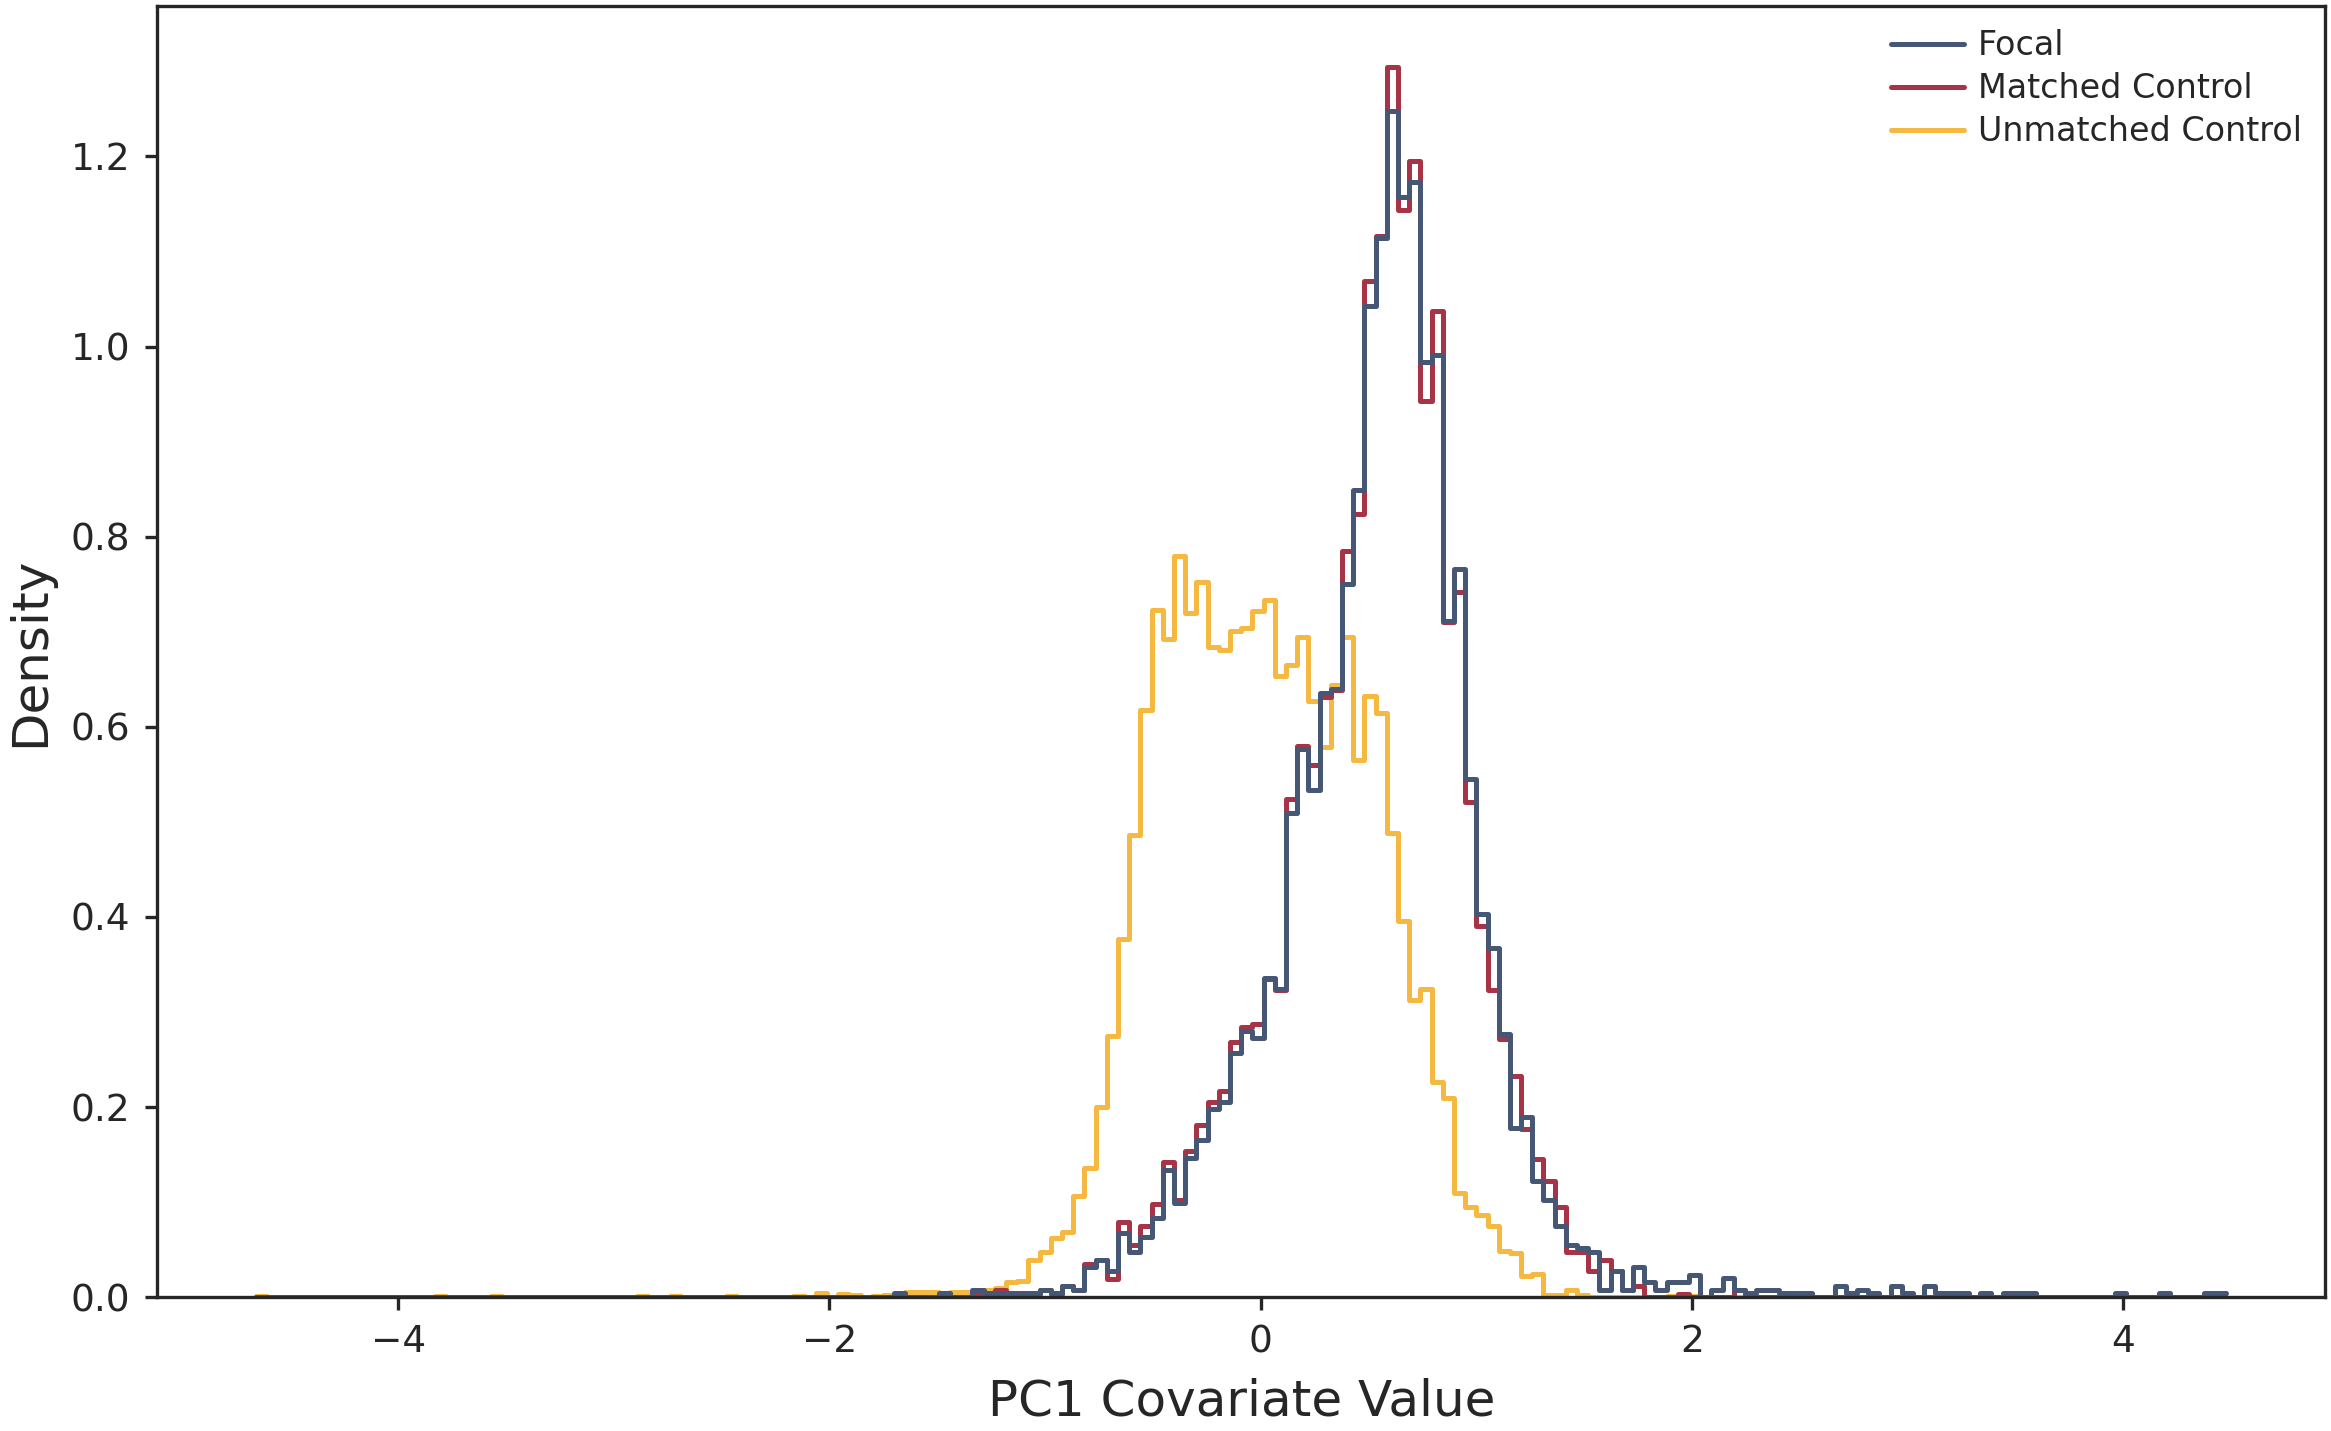

In [4]:
data_df = pd.read_csv(f'{data_dir}/ws_1000000/grid_search_data_pc1_10kb.csv')
split_dfs = split_df(data_df)

ctcf_signal_dict['pc1'] = {
    group: split_dfs[group]['ctcf_signal'].values
    for group in ['Focal', 'Matched Control']
}

insulation_efficiency_dict['pc1'] = {
    group: split_dfs[group]['ins_eff'].values
    for group in ['Focal', 'Matched Control']
}

_key = 'pc1_10kb'
density_plot_xlabel = 'PC1 Covariate Value'

smds[_key] = calculate_smd(
    split_dfs,
    contrast_labels=['Matched Control', 'Unmatched Control', 'Control Pool'],
    contrast_key=_key,
)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

density_plot = plot_distribution(
    {k:v for k, v in split_dfs.items() if k in ['Focal', 'Matched Control', 'Unmatched Control']},
    contrast_key=_key,
    x_label=density_plot_xlabel,
    y_label='Density',
    ax=ax,
)

fig.tight_layout()
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/smd_{_key}_distribution.svg', format='svg', dpi=300)

### atac-seq and h3k4me3

Focal: 3252 samples
Matched Control: 3256 samples
Unmatched Control: 18887 samples
Control Pool: 22143 samples


/tmp/ipykernel_303961/386242561.py:48: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  s = sns.histplot(
/tmp/ipykernel_303961/386242561.py:48: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  s = sns.histplot(


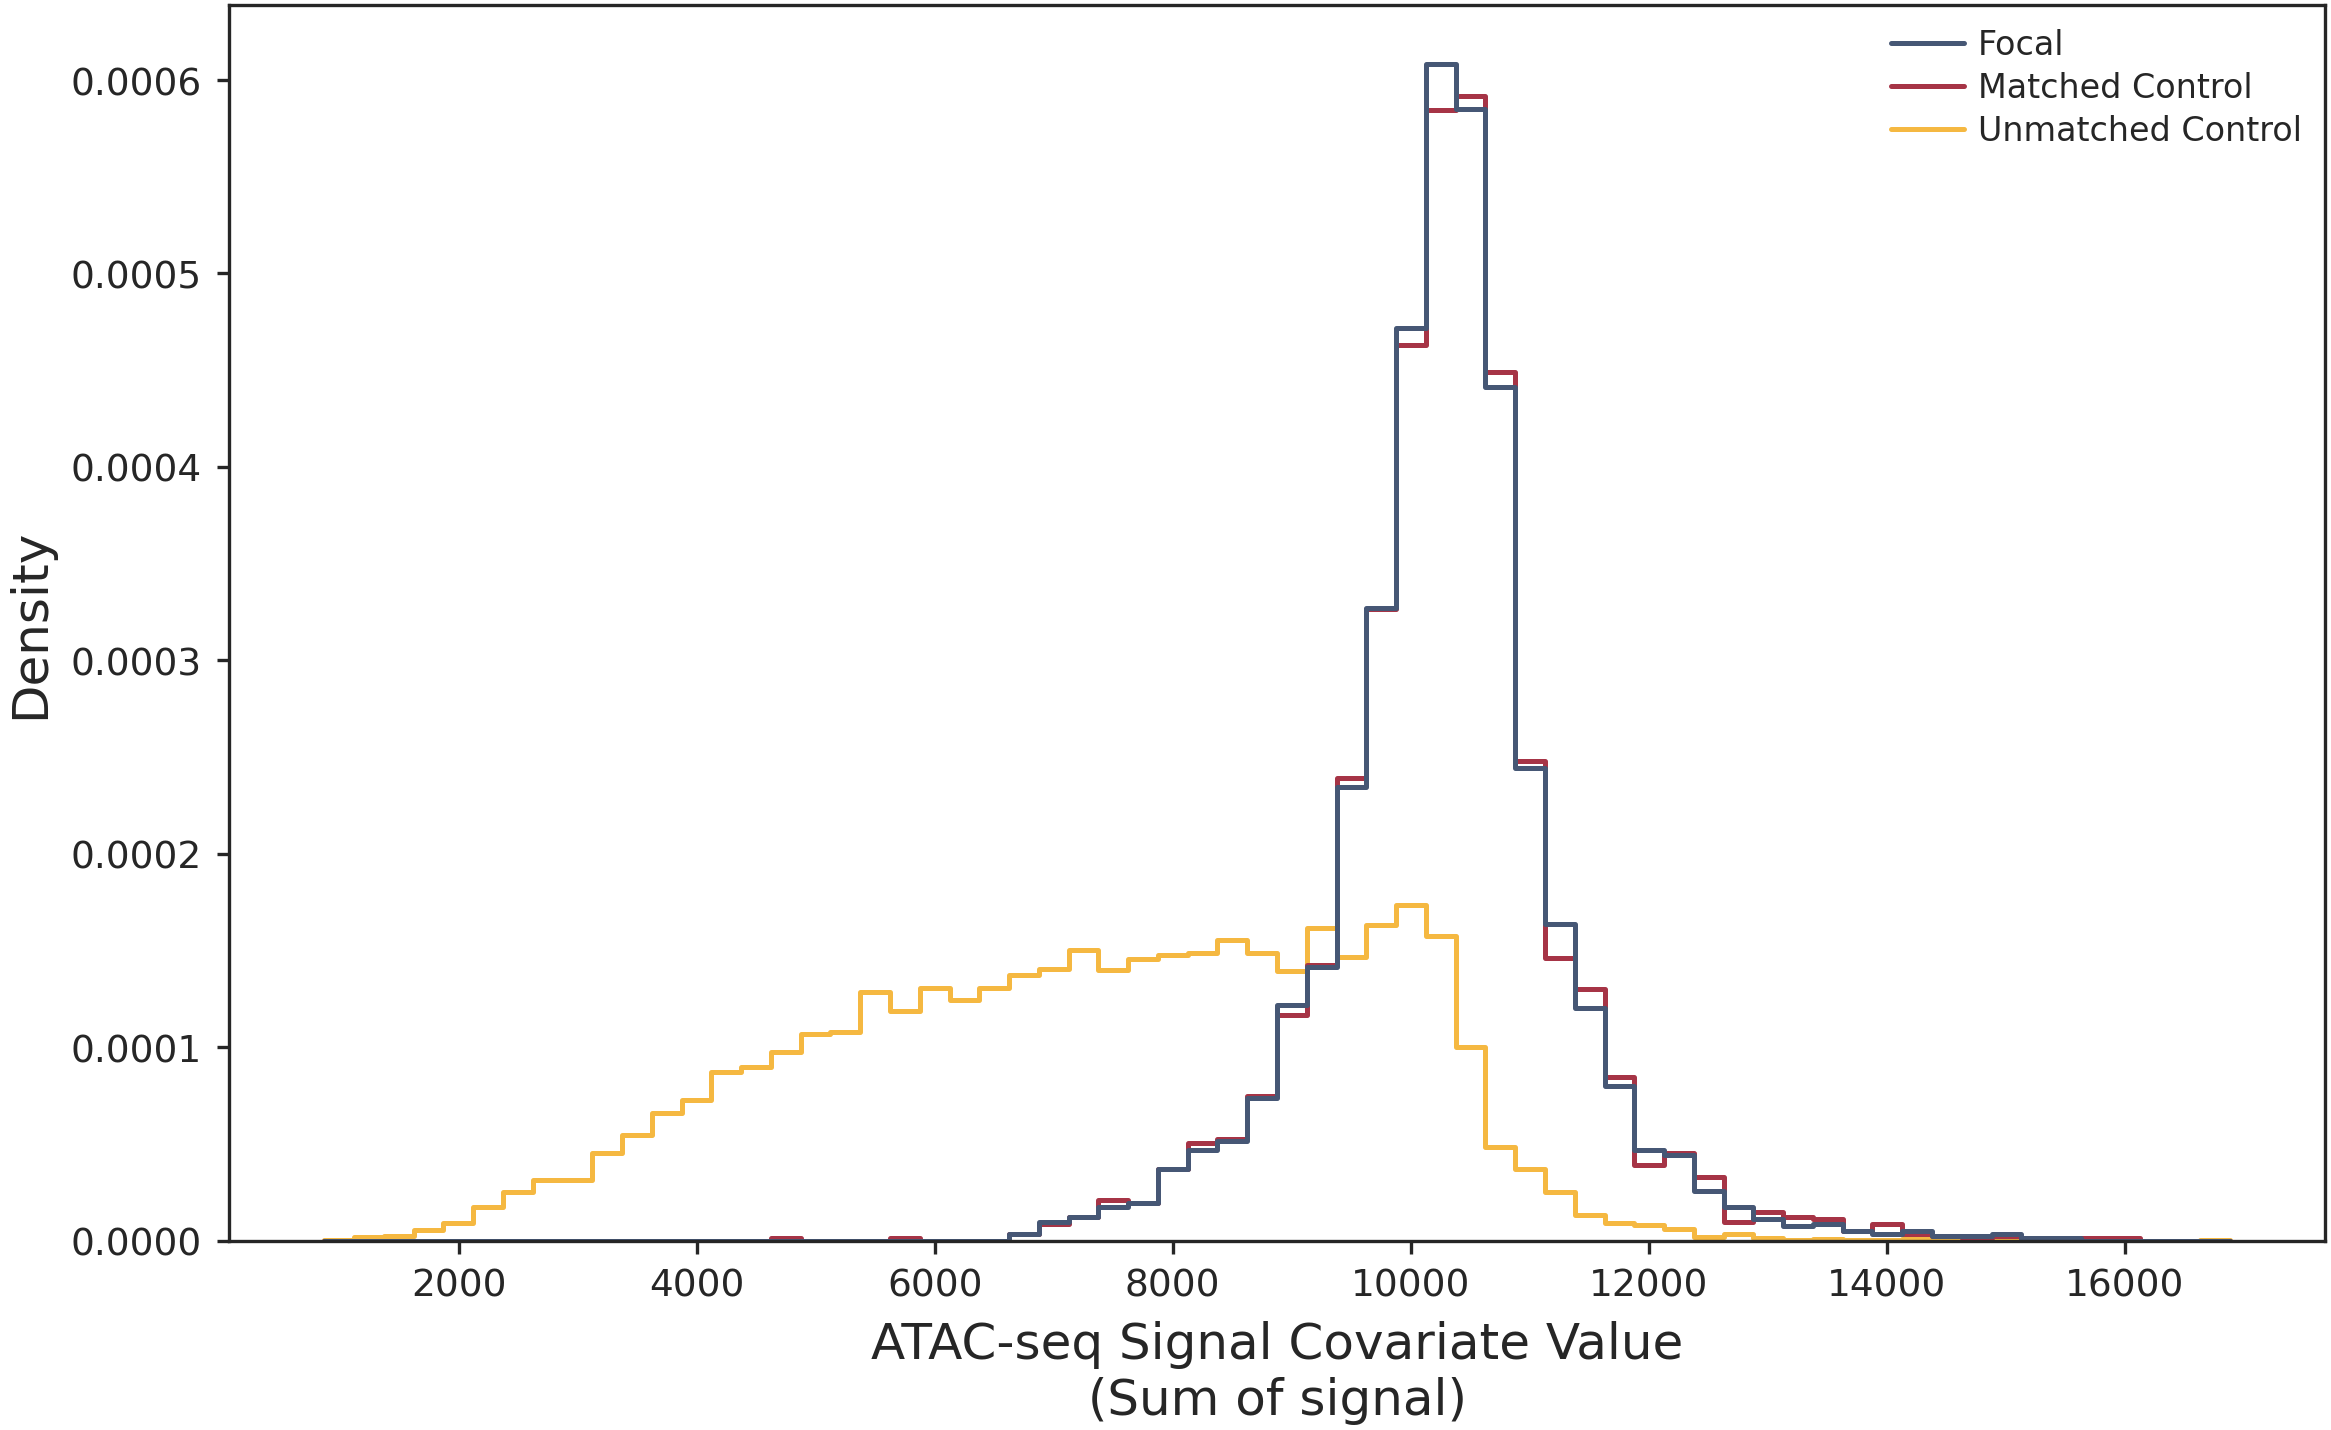

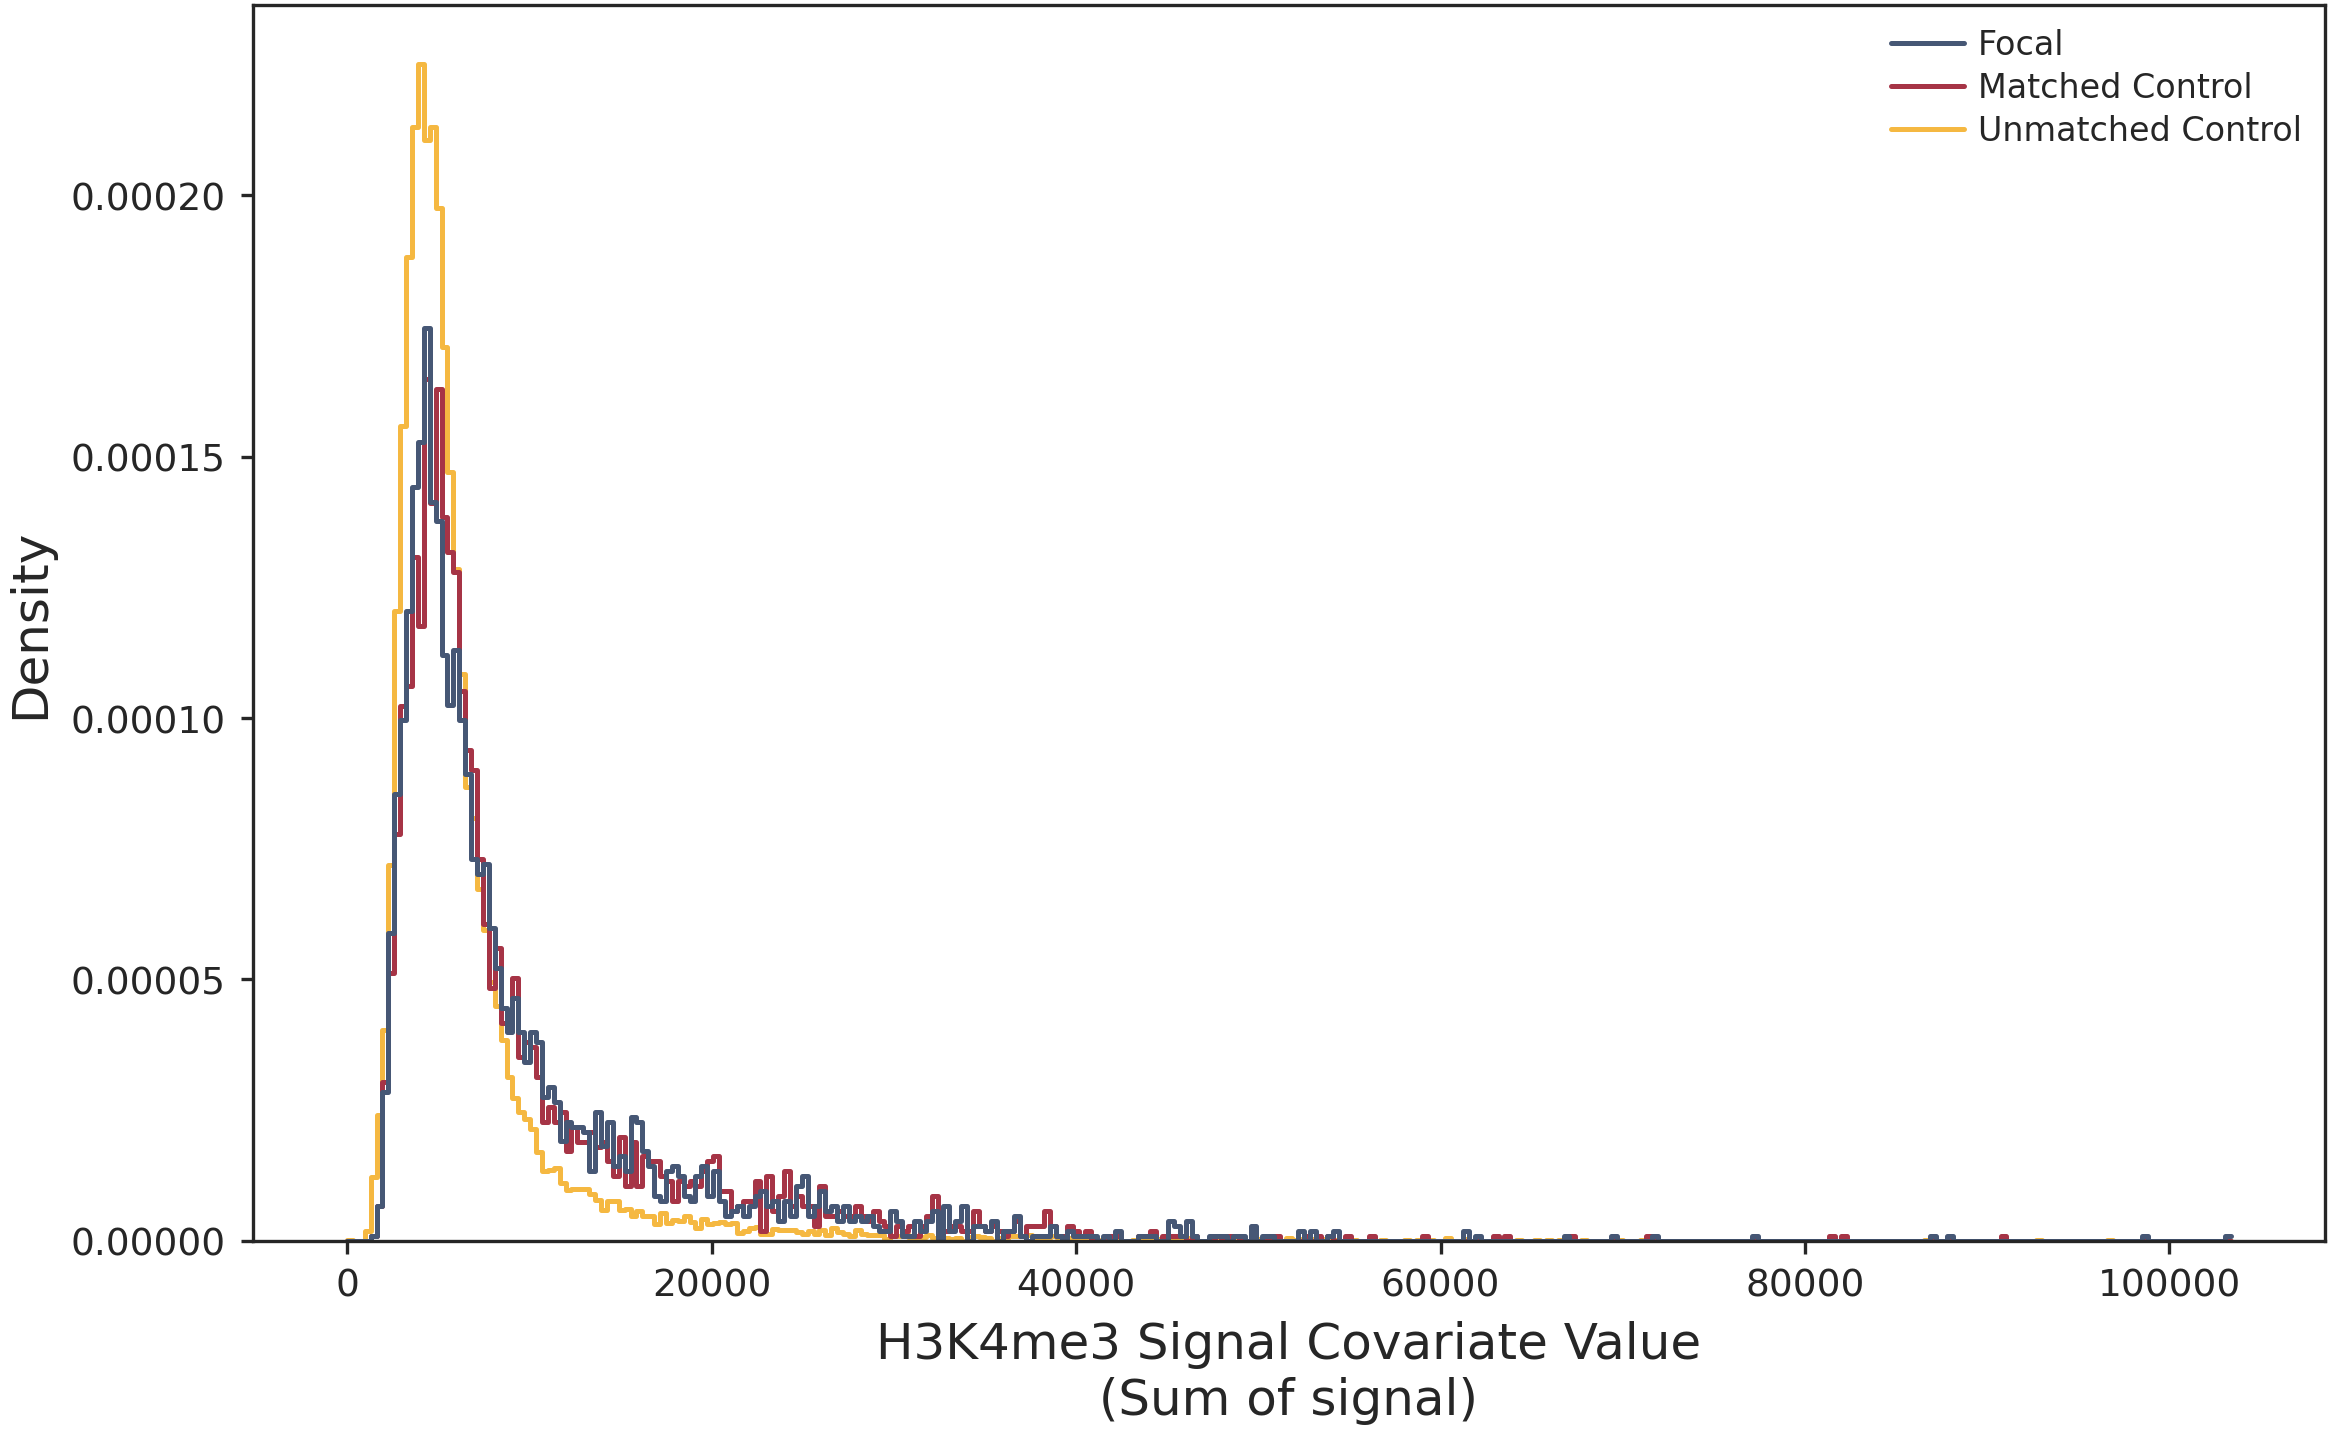

In [5]:
data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_atac_signal_h3k4me3_signal.csv')
split_dfs = split_df(data_df)

ctcf_signal_dict['atac_h3k4me3'] = {
    group: split_dfs[group]['ctcf_signal'].values
    for group in ['Focal', 'Matched Control']
}

insulation_efficiency_dict['atac_h3k4me3'] = {
    group: split_dfs[group]['ins_eff'].values
    for group in ['Focal', 'Matched Control']
}

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

_key = 'atac_signal'
density_plot_xlabel = 'ATAC-seq Signal Covariate Value\n(Sum of signal)'

smds[_key] = calculate_smd(
    split_dfs,
    contrast_labels=['Matched Control', 'Unmatched Control', 'Control Pool'],
    contrast_key=_key,
)

density_plot = plot_distribution(
    {k:v for k, v in split_dfs.items() if k in ['Focal', 'Matched Control', 'Unmatched Control']},
    contrast_key=_key,
    x_label=density_plot_xlabel,
    y_label='Density',
    ax=ax,
)

fig.tight_layout()
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/smd_atac_distribution.svg', format='svg', dpi=300)

_key = 'h3k4me3_signal'
density_plot_xlabel = 'H3K4me3 Signal Covariate Value\n(Sum of signal)'

smds[_key] = calculate_smd(
    split_dfs,
    contrast_labels=['Matched Control', 'Unmatched Control', 'Control Pool'],
    contrast_key=_key,
)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

density_plot = plot_distribution(
    {k:v for k, v in split_dfs.items() if k in ['Focal', 'Matched Control', 'Unmatched Control']},
    contrast_key=_key,
    x_label=density_plot_xlabel,
    y_label='Density',
    ax=ax,
)

fig.tight_layout()
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/smd_h3k4me3_distribution.svg', format='svg', dpi=300)

### h3k4me1 and h3k27ac

Focal: 3252 samples
Matched Control: 3256 samples
Unmatched Control: 21166 samples
Control Pool: 24422 samples


/tmp/ipykernel_303961/386242561.py:48: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  s = sns.histplot(
/tmp/ipykernel_303961/386242561.py:48: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  s = sns.histplot(


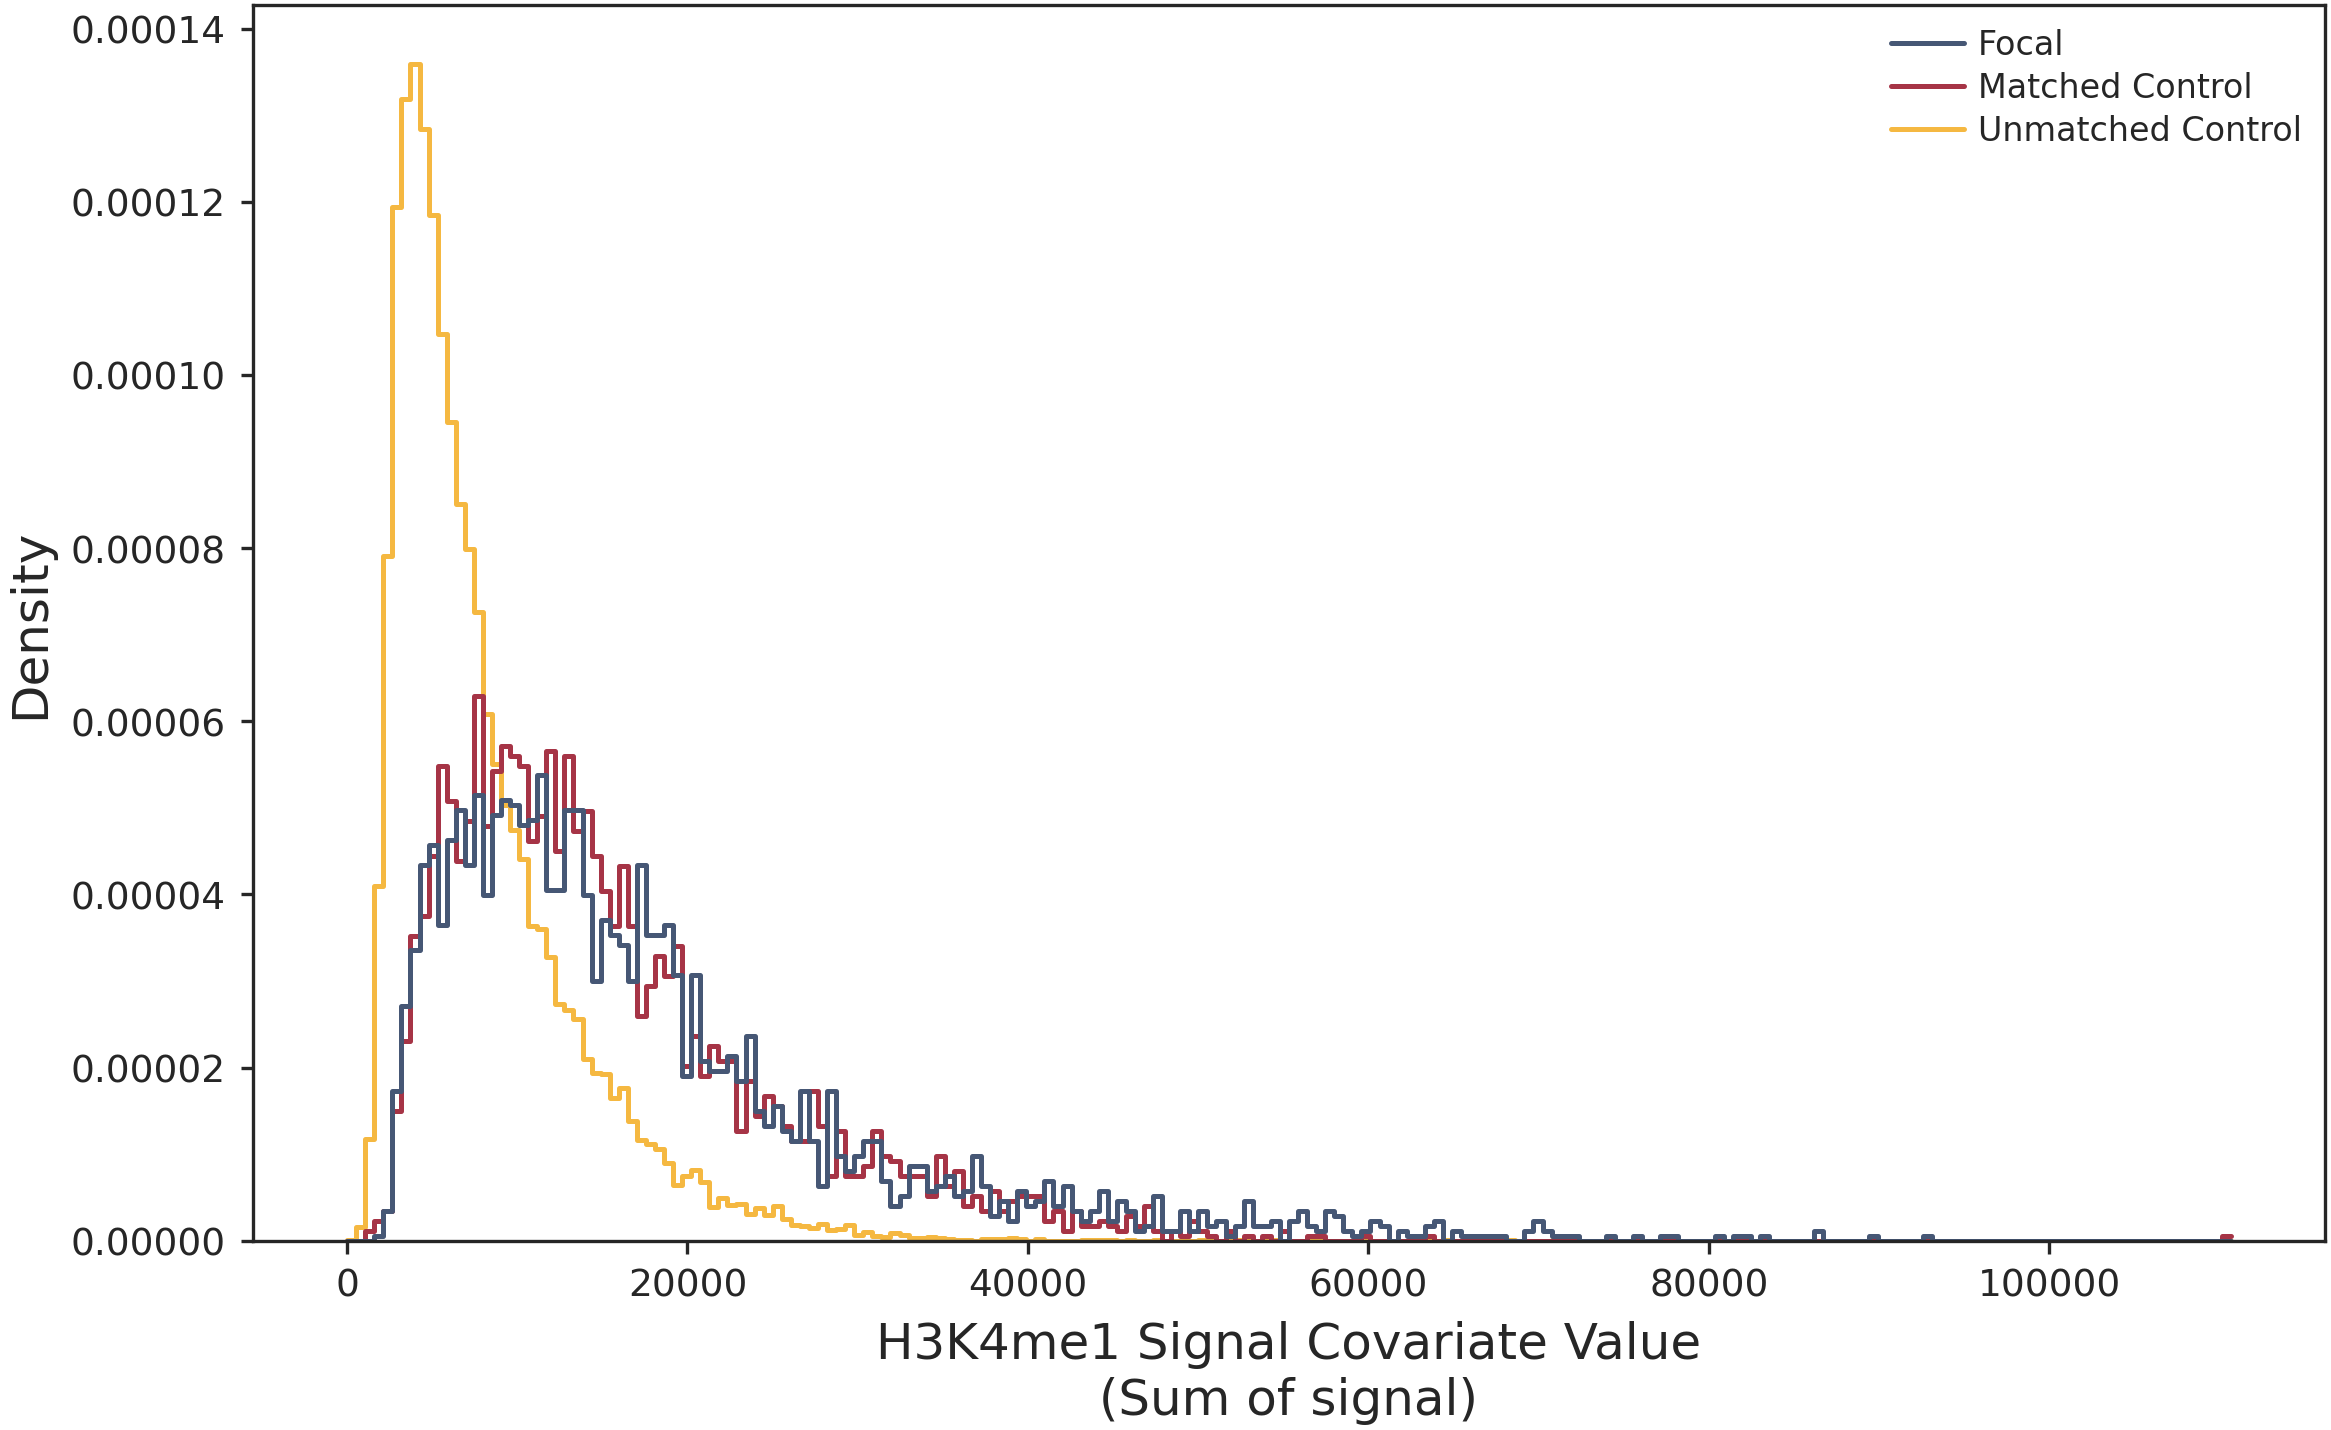

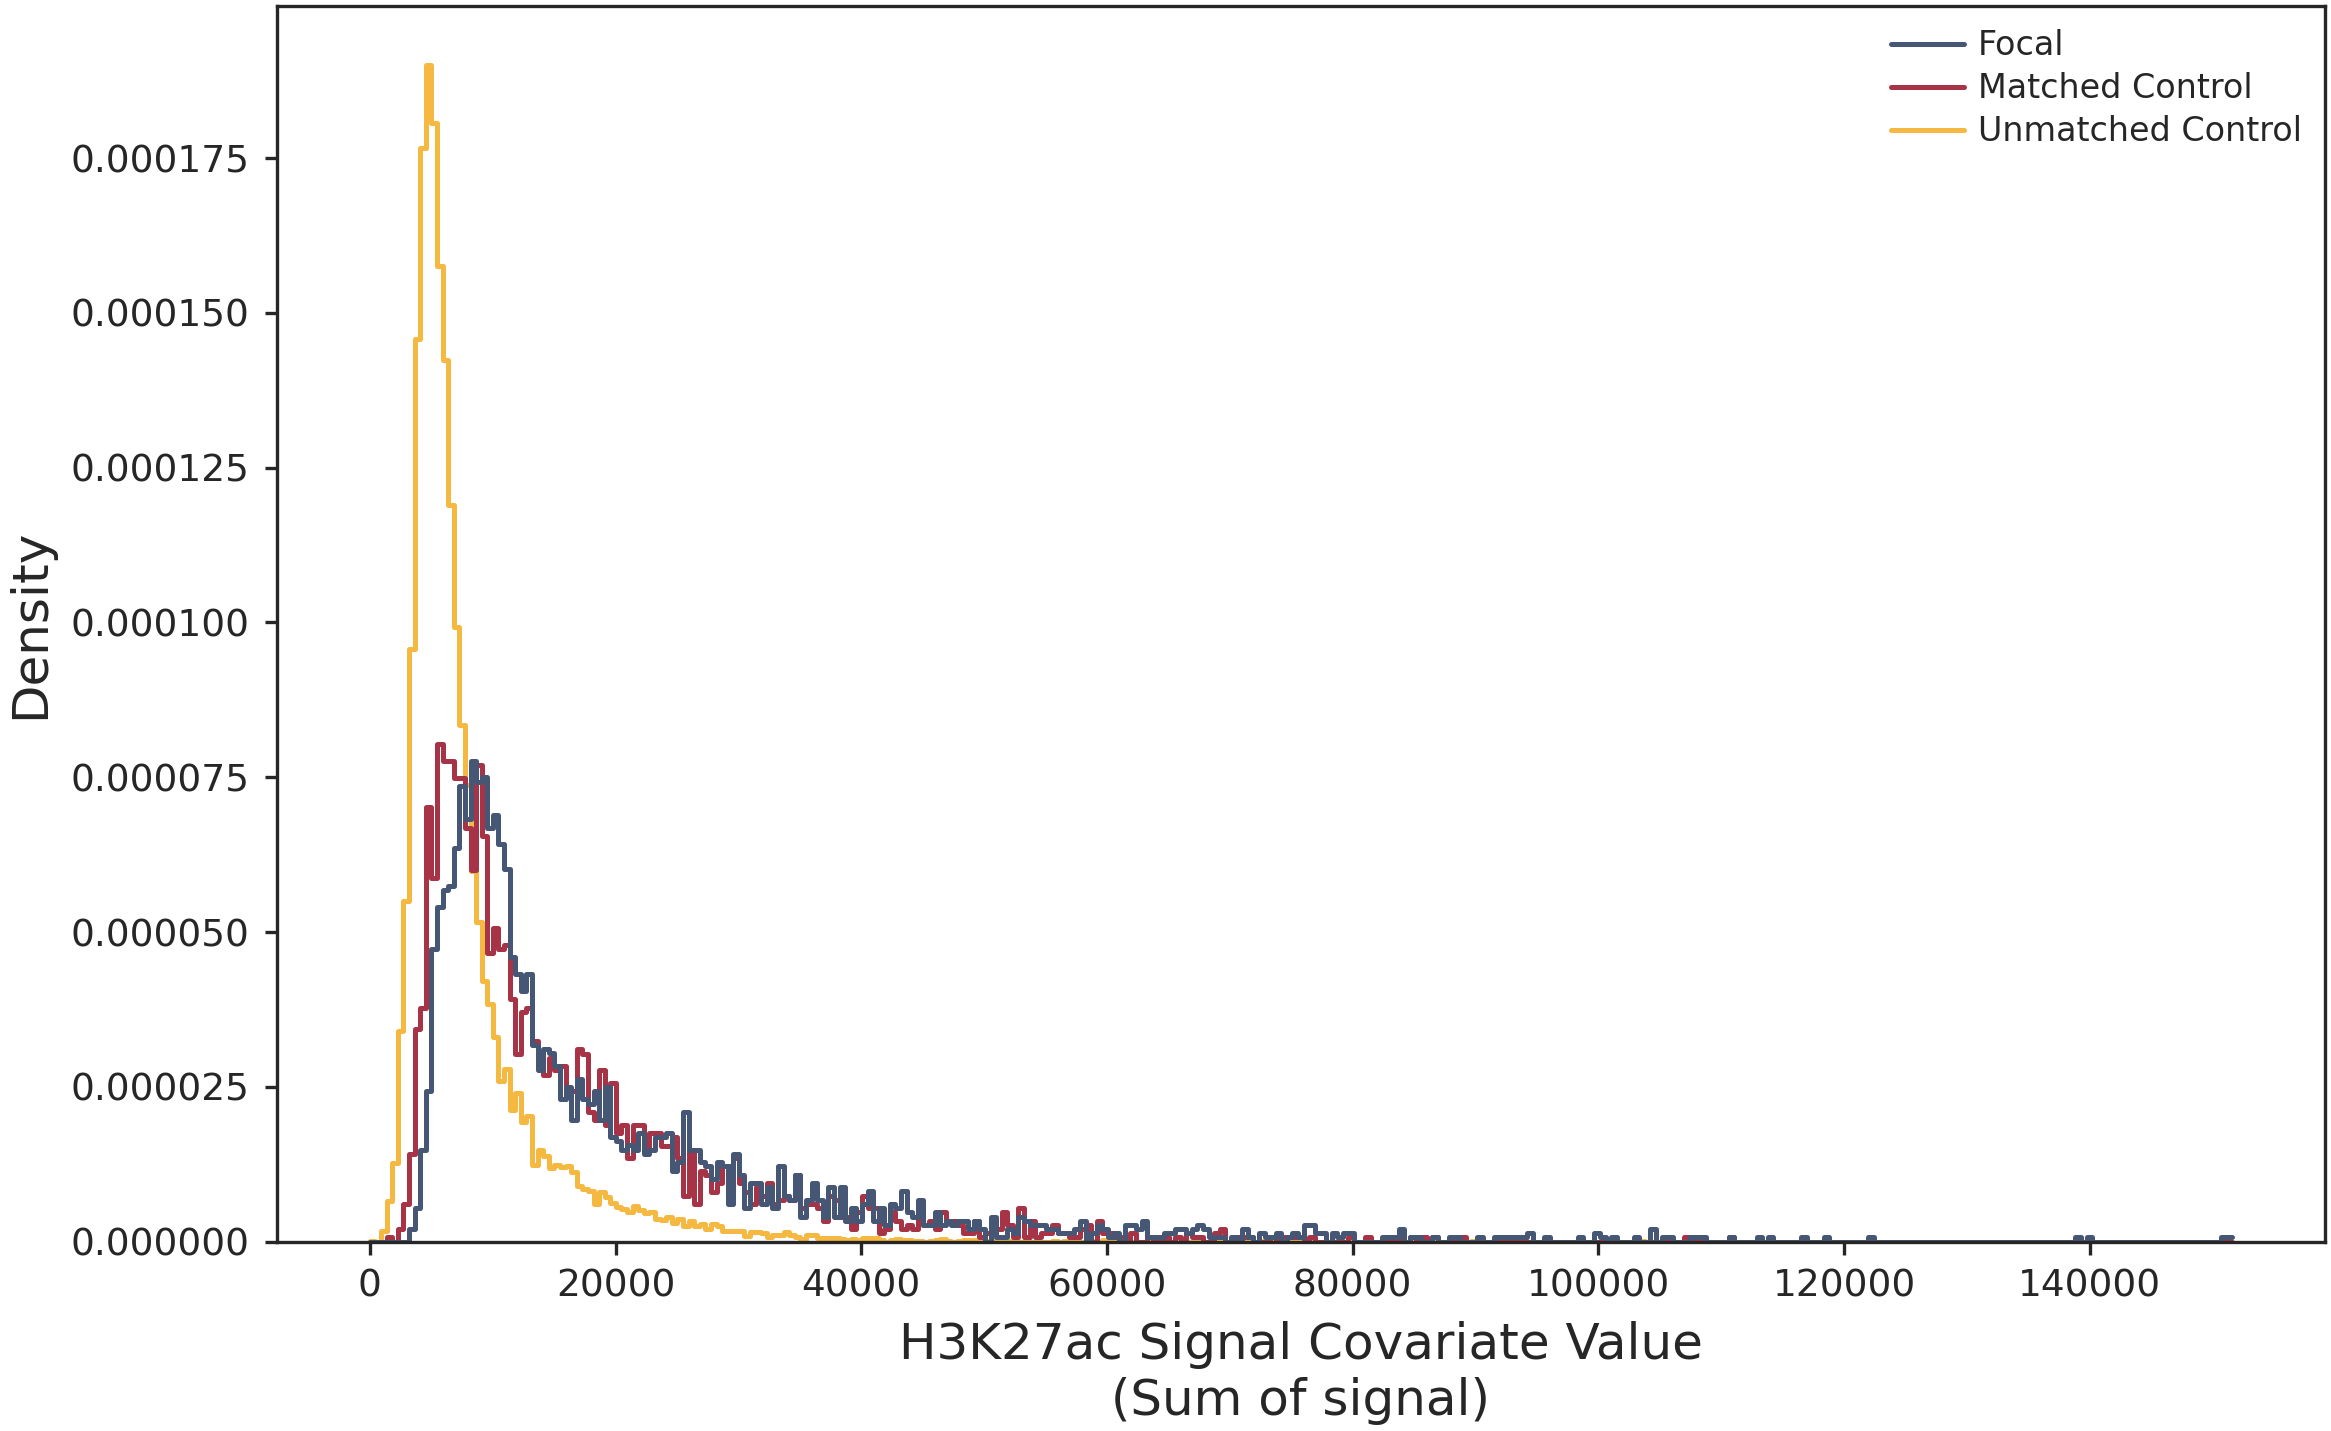

In [6]:
data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_h3k4me1_signal_h3k27ac_signal.csv')
split_dfs = split_df(data_df)

ctcf_signal_dict['h3k4me1_h3k27ac'] = {
    group: split_dfs[group]['ctcf_signal'].values
    for group in ['Focal', 'Matched Control']
}

insulation_efficiency_dict['h3k4me1_h3k27ac'] = {
    group: split_dfs[group]['ins_eff'].values
    for group in ['Focal', 'Matched Control']
}

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

_key = 'h3k4me1_signal'
density_plot_xlabel = 'H3K4me1 Signal Covariate Value\n(Sum of signal)'

smds[_key] = calculate_smd(
    split_dfs,
    contrast_labels=['Matched Control', 'Unmatched Control', 'Control Pool'],
    contrast_key=_key,
)

density_plot = plot_distribution(
    {k:v for k, v in split_dfs.items() if k in ['Focal', 'Matched Control', 'Unmatched Control']},
    contrast_key=_key,
    x_label=density_plot_xlabel,
    y_label='Density',
    ax=ax,
)

fig.tight_layout()
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/smd_h3k4me1_distribution.svg', format='svg', dpi=300)

_key = 'h3k27ac_signal'
density_plot_xlabel = 'H3K27ac Signal Covariate Value\n(Sum of signal)'

smds[_key] = calculate_smd(
    split_dfs,
    contrast_labels=['Matched Control', 'Unmatched Control', 'Control Pool'],
    contrast_key=_key,
)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

density_plot = plot_distribution(
    {k:v for k, v in split_dfs.items() if k in ['Focal', 'Matched Control', 'Unmatched Control']},
    contrast_key=_key,
    x_label=density_plot_xlabel,
    y_label='Density',
    ax=ax,
)

fig.tight_layout()
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/smd_h3k27ac_distribution.svg', format='svg', dpi=300)

### pol2

In [7]:
data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_pol2.csv')
split_dfs = split_df(data_df)

ctcf_signal_dict['pol2'] = {
    group: split_dfs[group]['ctcf_signal'].values
    for group in ['Focal', 'Matched Control']
}

insulation_efficiency_dict['pol2'] = {
    group: split_dfs[group]['ins_eff'].values
    for group in ['Focal', 'Matched Control']
}

Focal: 3577 samples
Matched Control: 3582 samples
Unmatched Control: 20841 samples
Control Pool: 24423 samples


/tmp/ipykernel_303961/386242561.py:48: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  s = sns.histplot(


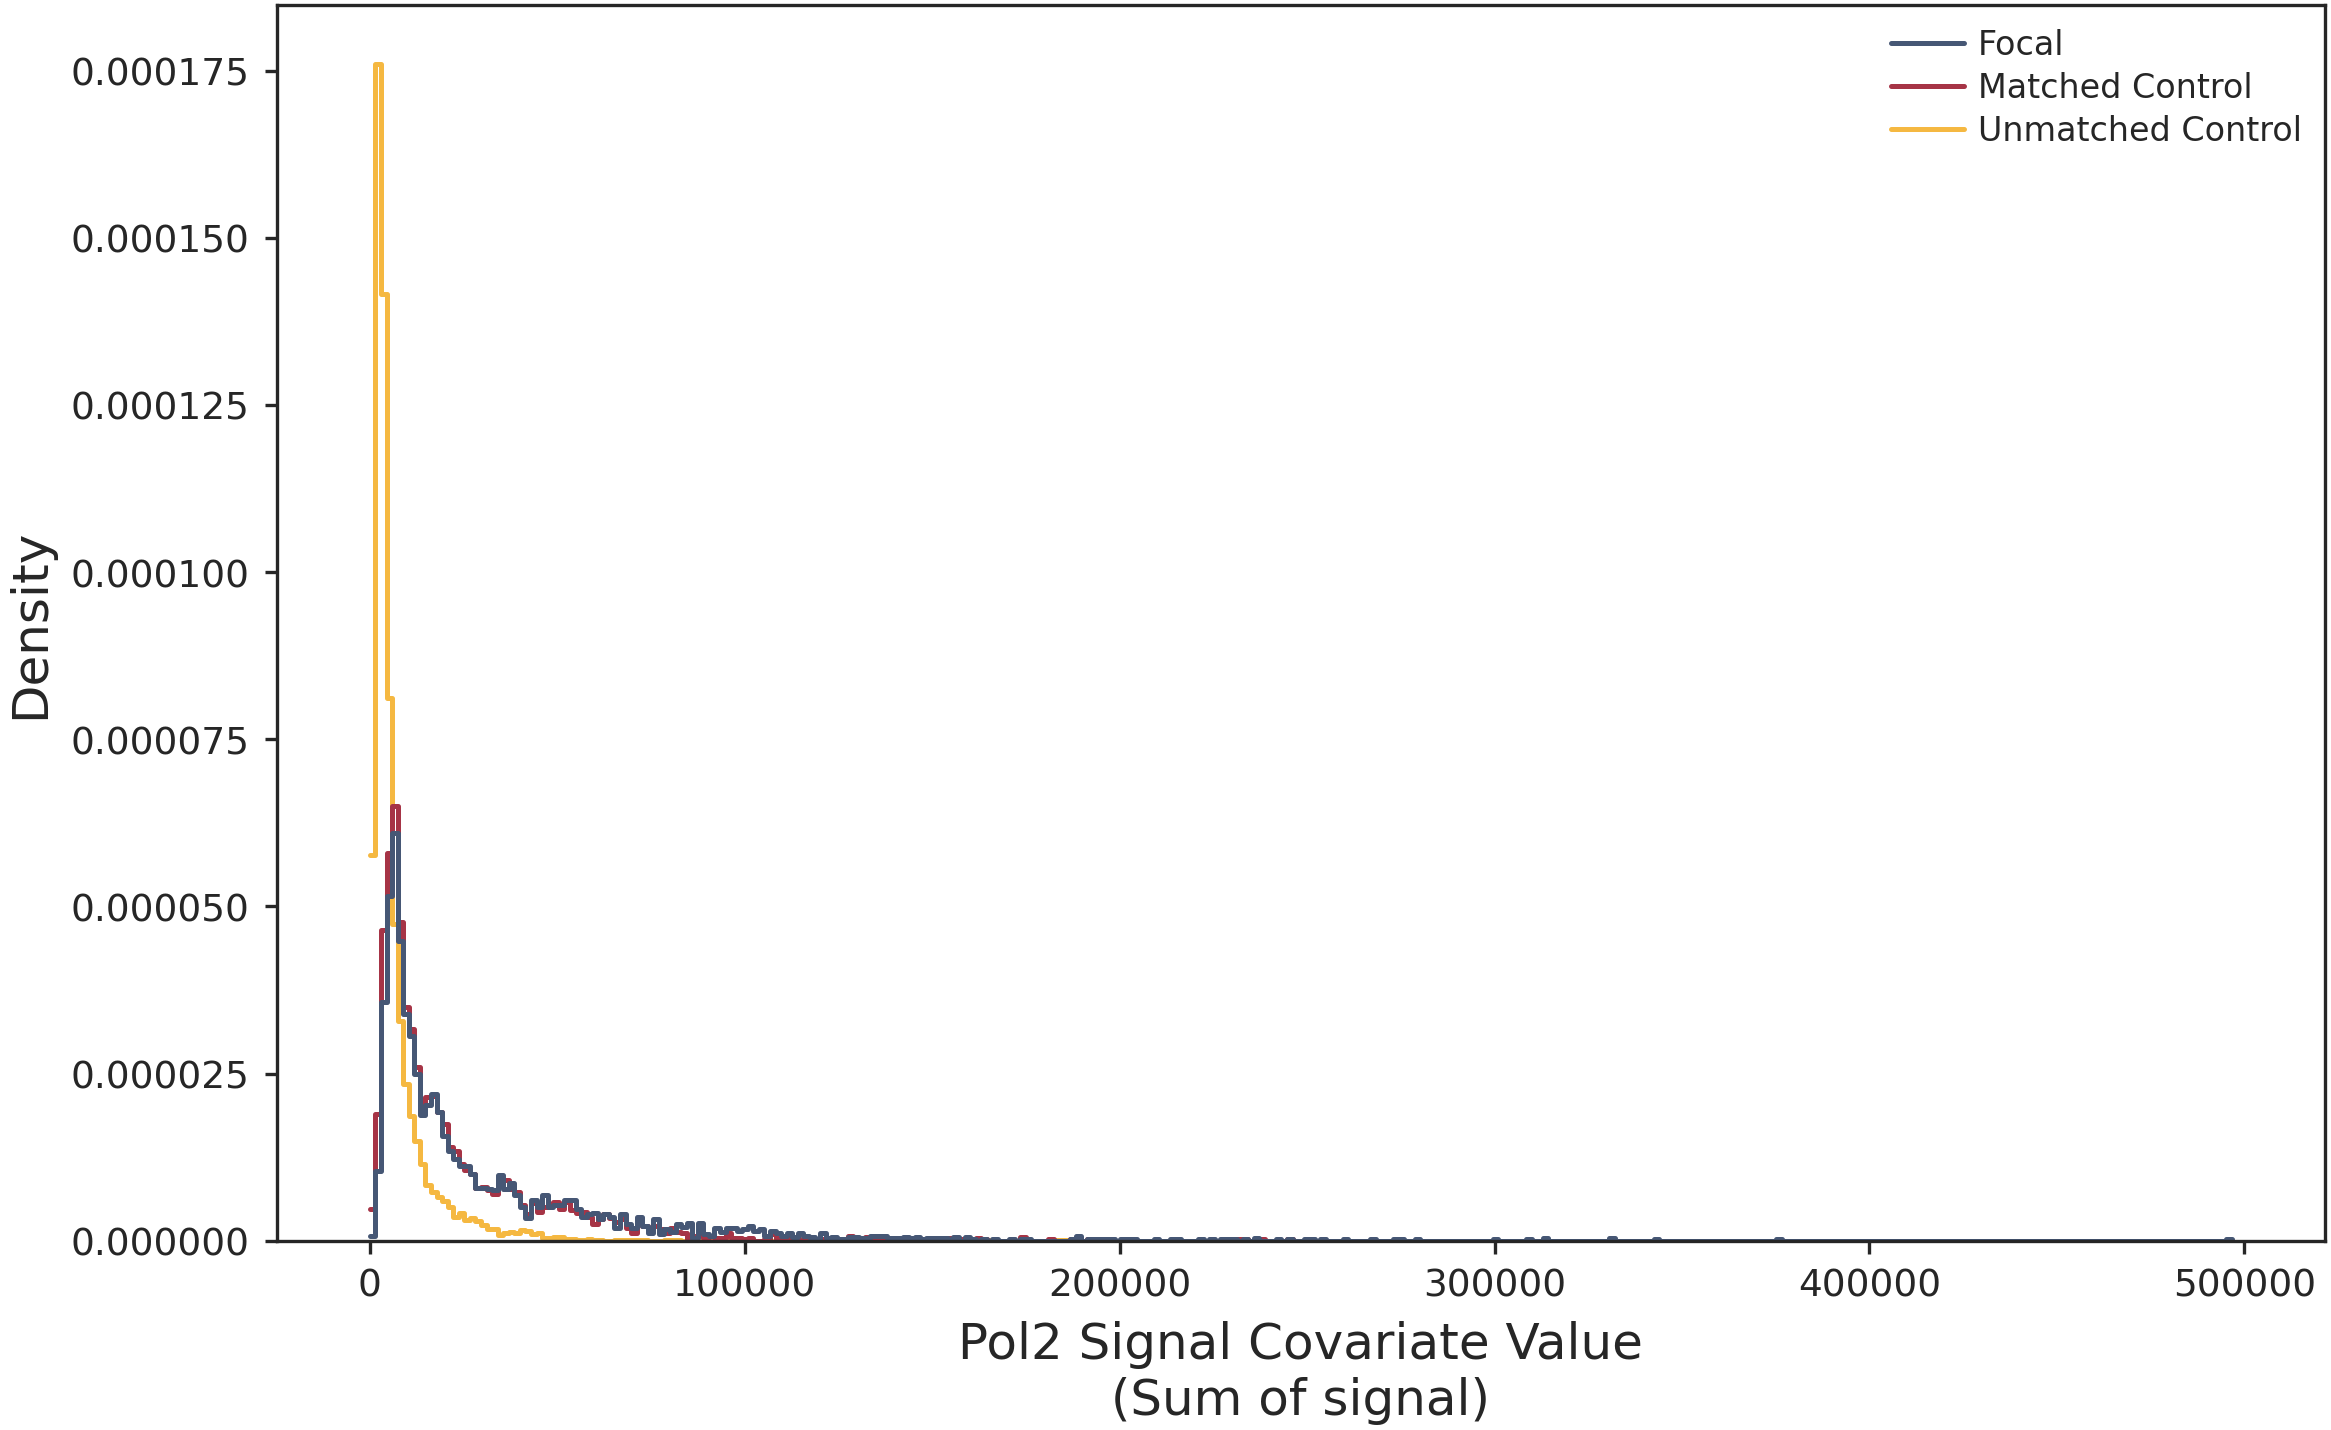

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

_key = 'pol2'
density_plot_xlabel = 'Pol2 Signal Covariate Value\n(Sum of signal)'

smds[_key] = calculate_smd(
    split_dfs,
    contrast_labels=['Matched Control', 'Unmatched Control', 'Control Pool'],
    contrast_key=_key,
)

density_plot = plot_distribution(
    {k:v for k, v in split_dfs.items() if k in ['Focal', 'Matched Control', 'Unmatched Control']},
    contrast_key=_key,
    x_label=density_plot_xlabel,
    y_label='Density',
    ax=ax,
)

fig.tight_layout()
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/smd_pol2_distribution.svg', format='svg', dpi=300)

### lollipop

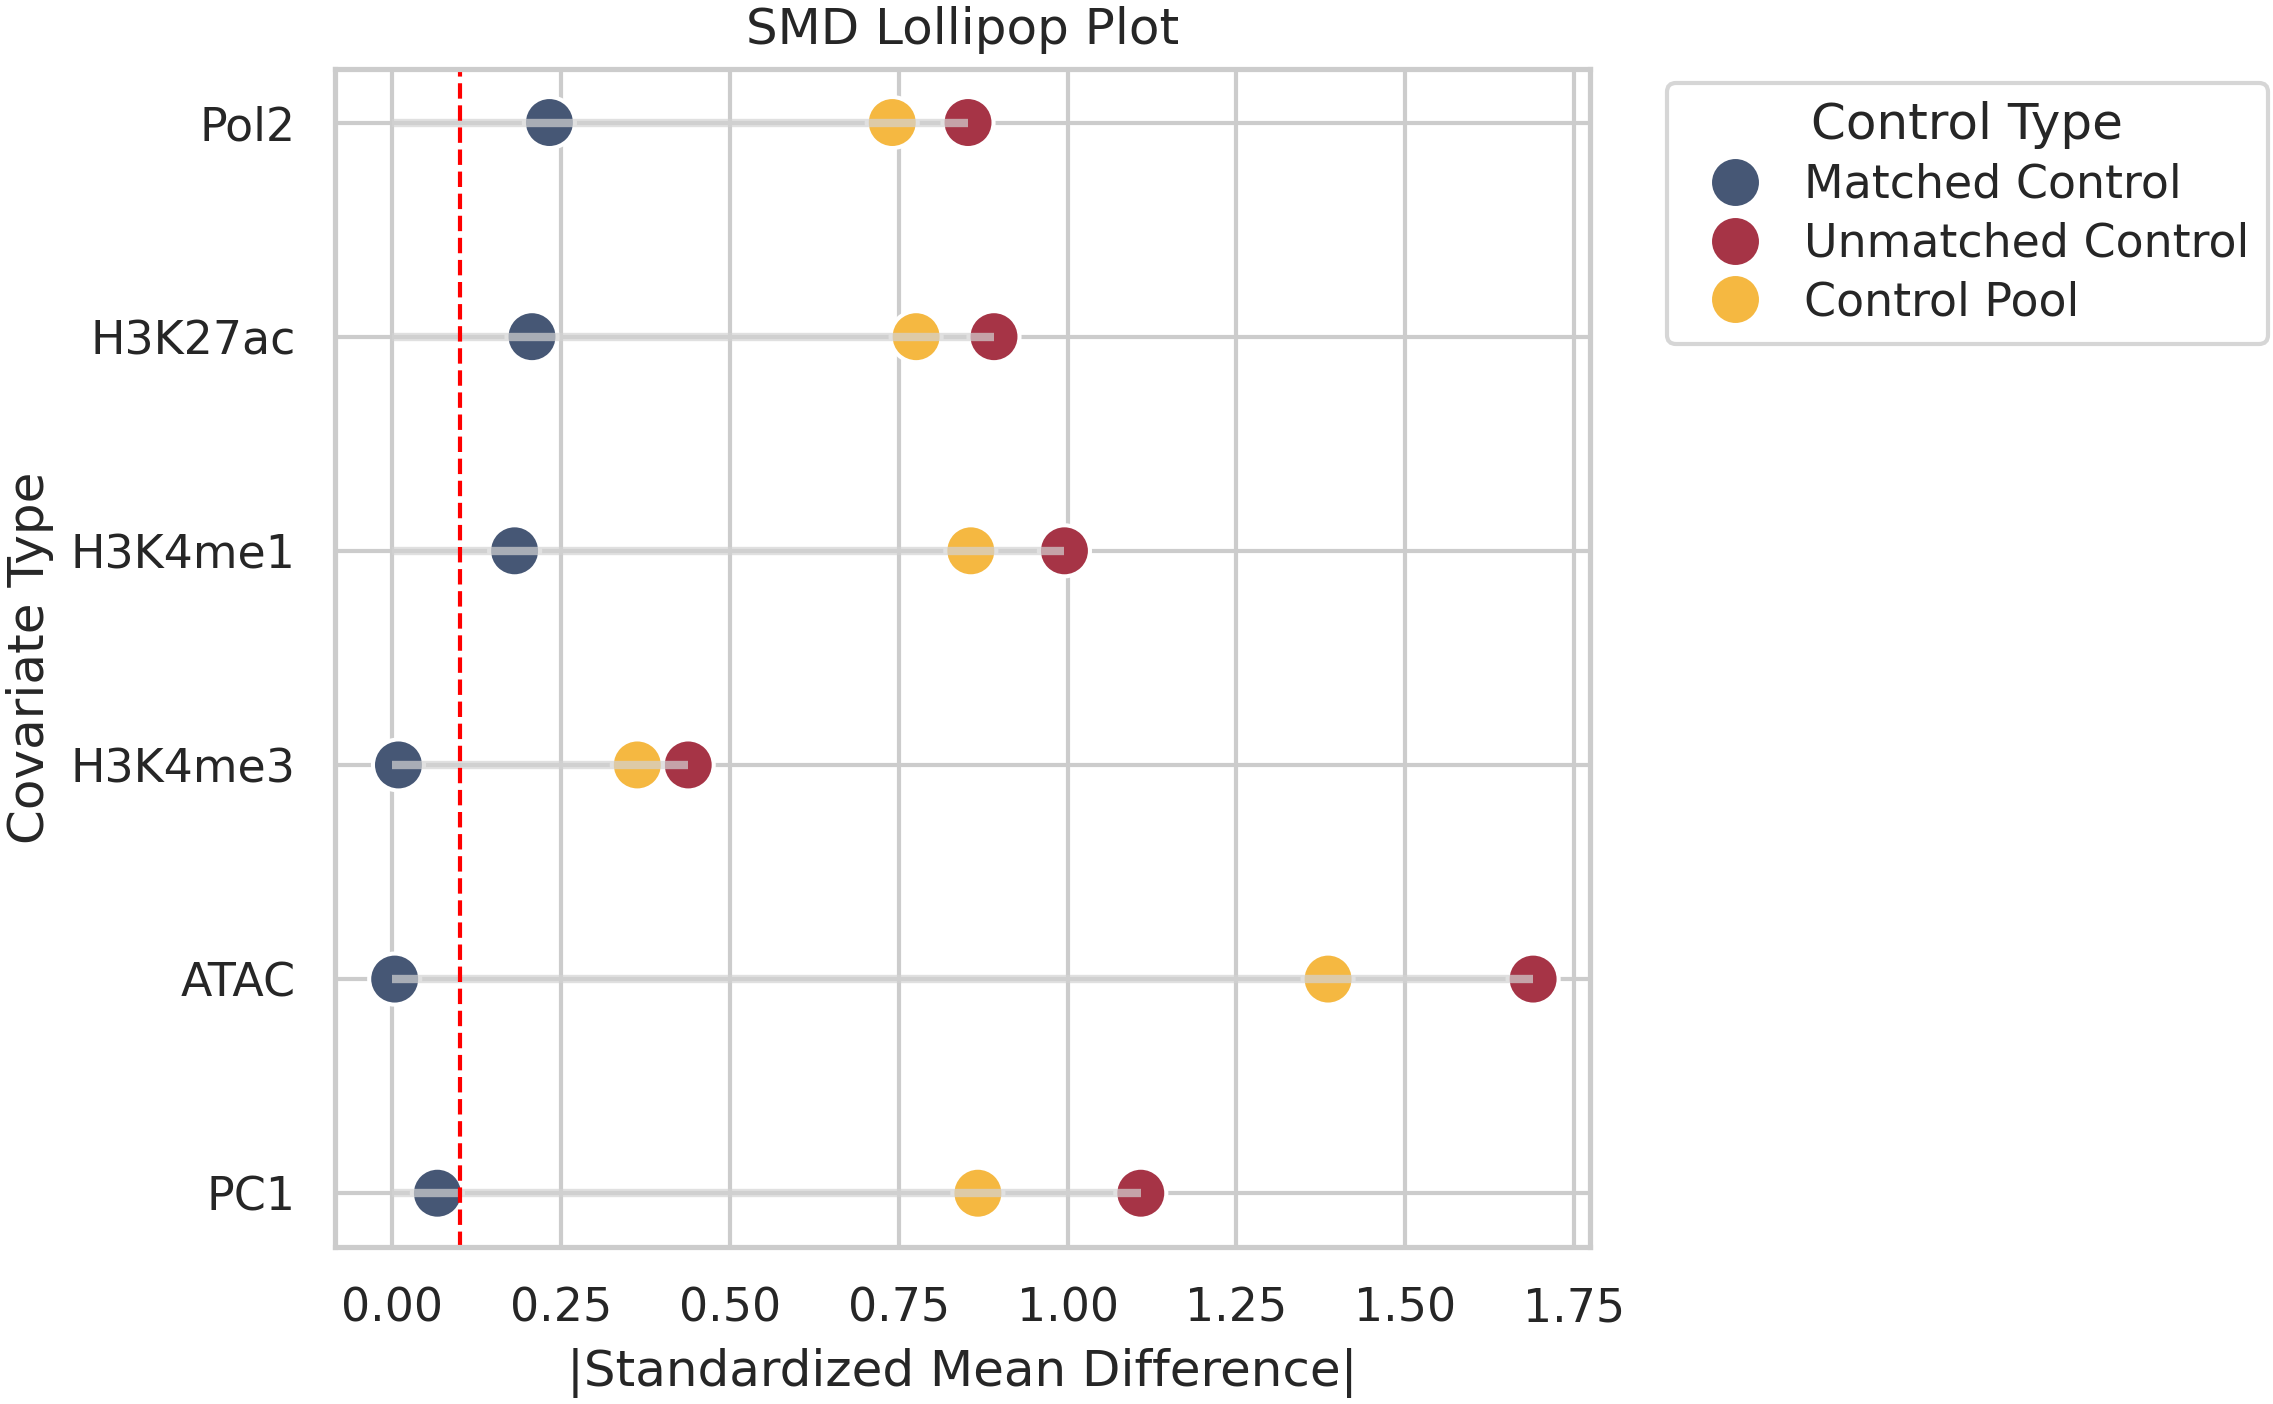

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert dict to dataframe
df = pd.DataFrame(smds).T
df_long = df.reset_index().melt(id_vars='index',
                                var_name='Control Type',
                                value_name='SMD')
df_long.rename(columns={'index': 'Feature'}, inplace=True)

name_map = {
    "pc1_10kb": "PC1",
    "atac_signal": "ATAC",
    "h3k4me3_signal": "H3K4me3",
    "h3k4me1_signal": "H3K4me1",
    "h3k27ac_signal": "H3K27ac",
    "pol2": "Pol2",
}

df_long["Feature"] = df_long["Feature"].map(name_map)

# Custom palette in correct order
palette = {
    'Matched Control': '#465775',
    'Unmatched Control': '#A63446',
    'Control Pool': '#F5B841'
}

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.set(style="whitegrid")

# ---- Draw horizontal lines per feature ----
features = df_long["Feature"].unique()

for i, feature in enumerate(features):
    subset = df_long[df_long["Feature"] == feature]
    xmax = subset["SMD"].max()
    plt.hlines(y=i, xmin=0, xmax=xmax, color="lightgray", lw=2, alpha=0.7)

# ---- Draw colored dots ----
s = sns.scatterplot(
    data=df_long,
    x="SMD",
    y=df_long["Feature"].apply(lambda f: list(features).index(f)),
    hue="Control Type",
    palette=palette,
    s=150,
    ax=ax
)

# Fix y-tick labels
plt.yticks(
    ticks=range(len(features)),
    labels=features
)

plt.xlabel("|Standardized Mean Difference|")
plt.ylabel("Covariate Type")
plt.title("SMD Lollipop Plot")

plt.legend(title="Control Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# add vline at 0.1
plt.axvline(x=0.1, color='red', linestyle='--', lw=1)

fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/smd_lollipop_plot.svg', format='svg', dpi=300)

### ctcf levels and insulation

In [10]:
# ----------------------------
# Helper: p-value → asterisks
# ----------------------------
def p_to_asterisks(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

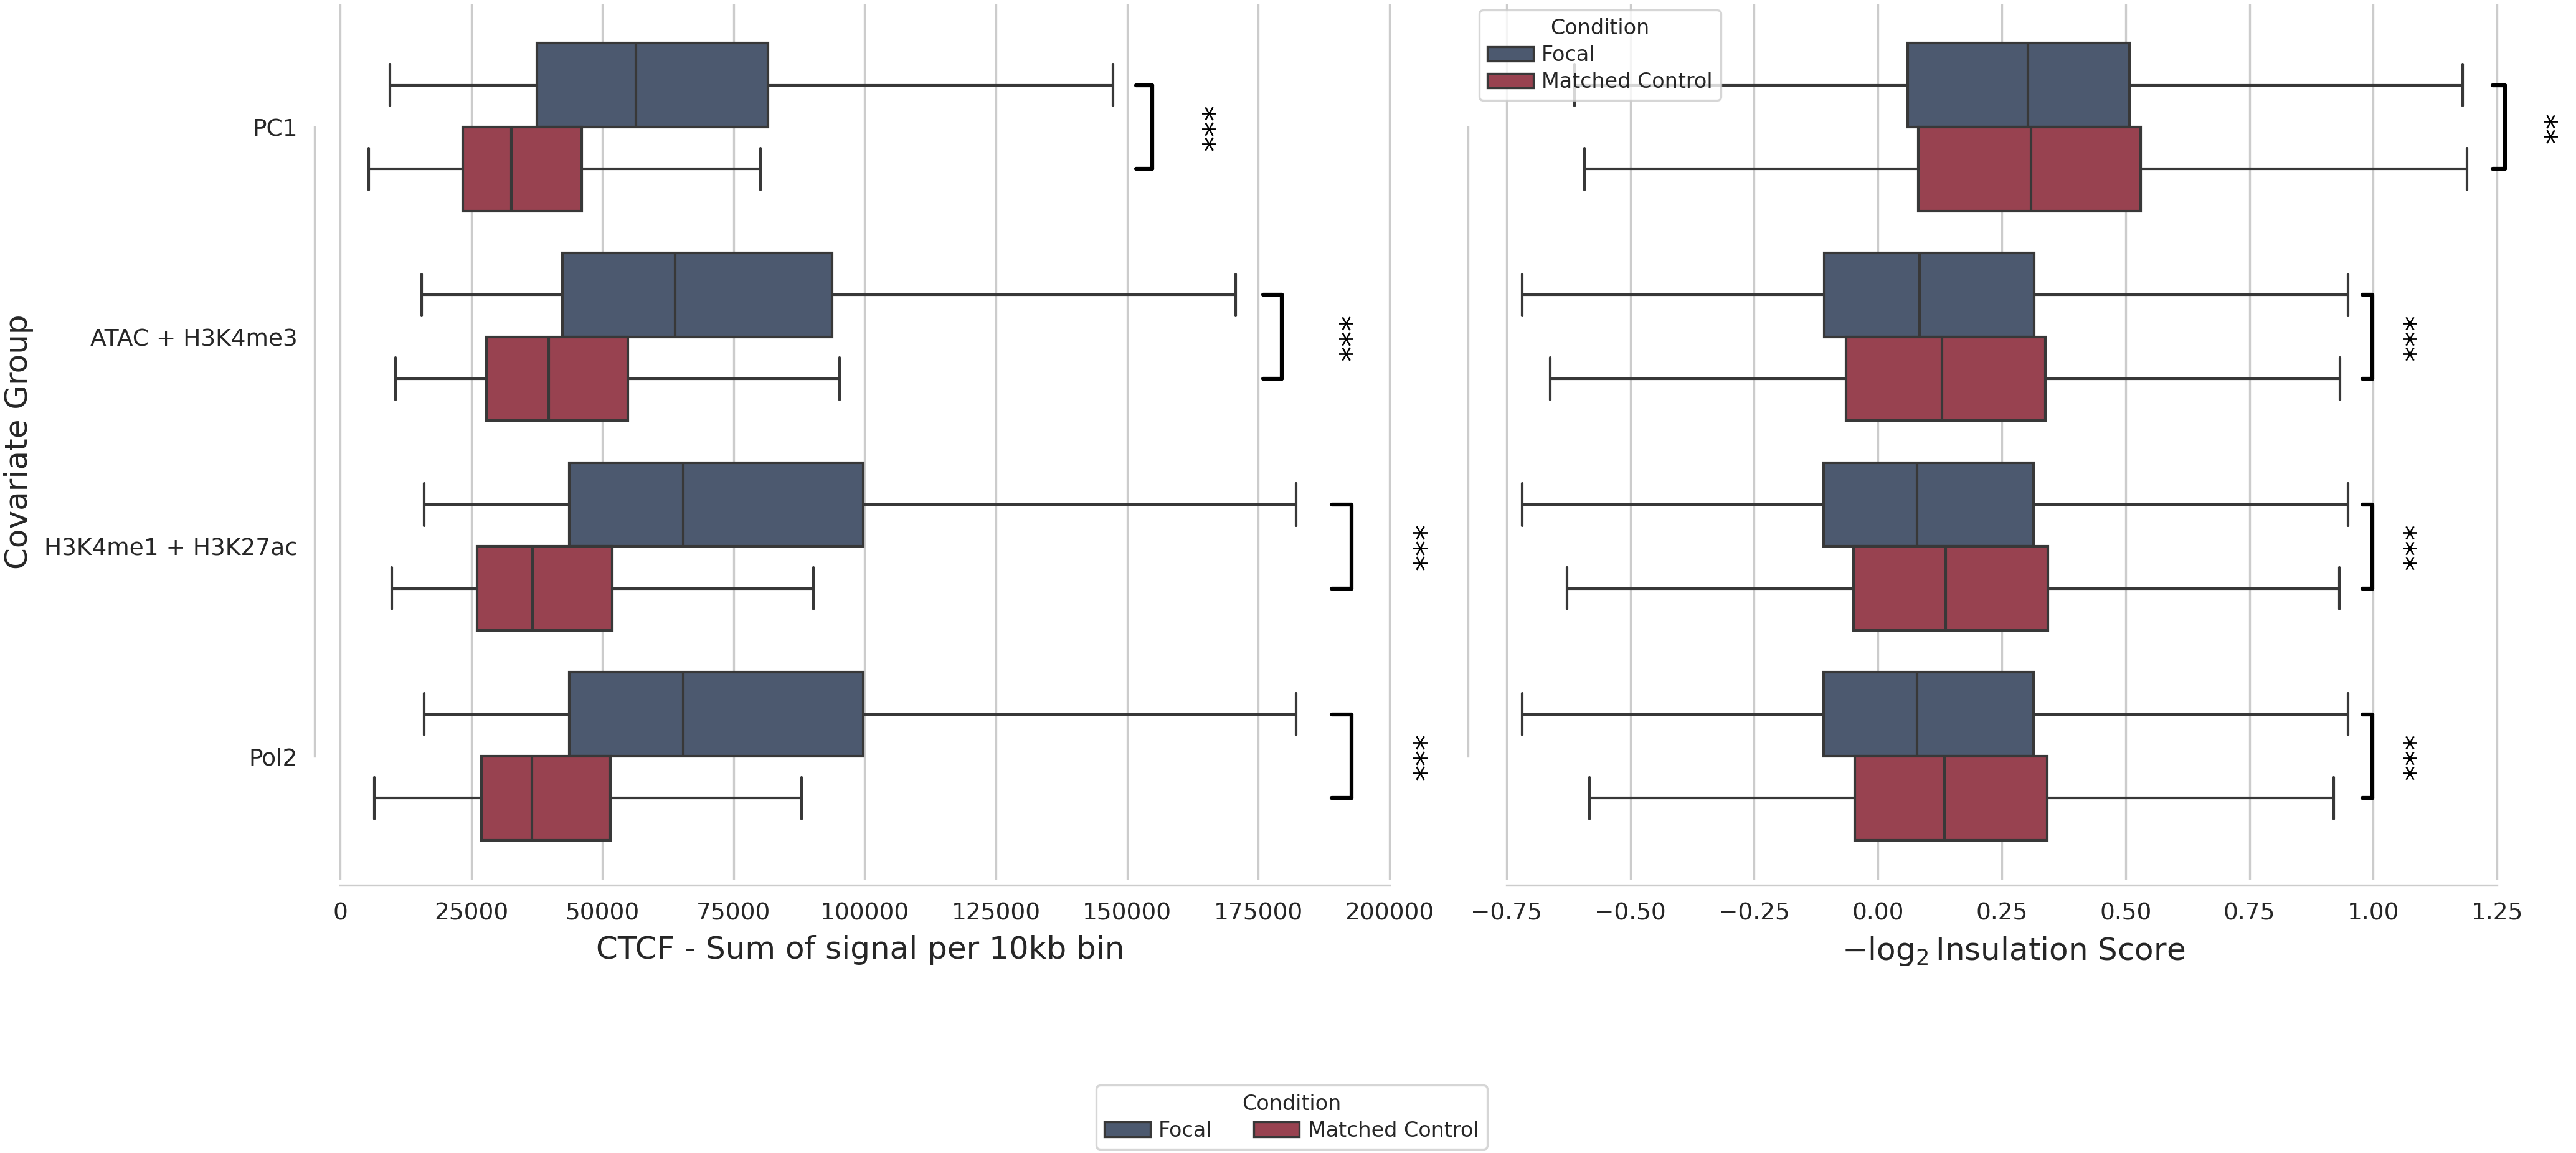

In [11]:
from ggner_3d import plotting
plotting.update_rcparams()

# --- Function to Prepare DataFrame ---
def prepare_df(data_dict):
    rows = []
    for covariate_type in data_dict.keys():
        for group in ['Focal', 'Matched Control']:
            signals = data_dict[covariate_type][group]
            for signal in signals:
                rows.append({
                    'Group': covariate_type,
                    'Condition': group,
                    'Signal': signal
                })
    df = pd.DataFrame(rows)
    
    label_mapping = {
        'pc1': f'PC1',
        'atac_h3k4me3': f'ATAC + H3K4me3',
        'h3k4me1_h3k27ac': f'H3K4me1 + H3K27ac',
        'pol2': f'Pol2',
    }
    df['Group'] = df['Group'].replace(label_mapping)
    return df

# --- Function to Draw Boxplot and Annotate Statistics ---
def plot_and_annotate(ax, df, x_label, palette):
    sns.boxplot(data=df, y='Group', x='Signal', hue='Condition', 
                orient='h', showfliers=False, palette=palette, ax=ax,
                # Ensure the order of groups is the same for shared Y-axis
                order=['PC1', 'ATAC + H3K4me3', 'H3K4me1 + H3K27ac', 'Pol2'])
    
    # Statistical Annotation
    groups = df['Group'].unique()
    hue_order = ['Focal', 'Matched Control']
    y_mapping = {g: i for i, g in enumerate(groups)}
    
    for group in groups:
        focal_data = df[(df['Group'] == group) & (df['Condition'] == 'Focal')]['Signal']
        control_data = df[(df['Group'] == group) & (df['Condition'] == 'Matched Control')]['Signal']
        
        # Perform Test
        stat, pval = mannwhitneyu(focal_data, control_data, alternative='two-sided')

        # Convert to asterisks
        p_text = p_to_asterisks(pval)
        
        # Determine position
        y = y_mapping[group]
        
        # Compute visual max (whisker)
        max_val = 0
        for cond in hue_order:
            d = df[(df['Group'] == group) & (df['Condition'] == cond)]['Signal']
            if d.empty: continue
            q1 = d.quantile(0.25)
            q3 = d.quantile(0.75)
            iqr = q3 - q1
            whisker = q3 + 1.5 * iqr
            visual_max = min(d.max(), whisker)
            if visual_max > max_val:
                max_val = visual_max
        
        # Draw bracket
        x_line = max_val * 1.05 # Adjust multiplier as needed for aesthetic spacing
        y1 = y - 0.2
        y2 = y + 0.2

        ax.plot([x_line, x_line], [y1, y2], color='black', lw=1.5, clip_on=False)
        ax.plot([x_line * 0.98, x_line], [y1, y1], color='black', lw=1.5, clip_on=False)
        ax.plot([x_line * 0.98, x_line], [y2, y2], color='black', lw=1.5, clip_on=False)

        # Asterisk label
        ax.text(x_line * 1.06, y, p_text, va='center', ha='left', color='black', fontsize=12, rotation=90, clip_on=False)
    
    ax.set_xlabel(x_label)
    # Remove the default Y-axis label/ticks which will be set on the shared Y-axis
    ax.set_ylabel('')


# --- Execution of the Combined Plot ---
df_ctcf = prepare_df(ctcf_signal_dict)
df_insulation = prepare_df(insulation_efficiency_dict)

sns.set_style("whitegrid")
palette = {'Focal': COLORS[0], 'Matched Control': COLORS[1]}

# 1. Setup the 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True) 

# 2. Plot CTCF Signal
plot_and_annotate(axes[0], df_ctcf, 
                  x_label='CTCF - Sum of signal per 10kb bin', 
                  palette=palette)
# axes[0].set_title('CTCF Signal', fontsize=14)

# 3. Plot Insulation Efficiency
plot_and_annotate(axes[1], df_insulation, 
                  x_label=r'$-\log_{2}\text{Insulation Score}$', 
                  palette=palette)
# axes[1].set_title('Insulation Efficiency', fontsize=14)

# 4. Set shared Y-axis label/ticks on the left subplot (axes[0])
axes[0].set_ylabel('Covariate Group', fontsize=12)

# 5. Extract and transfer Legend from one subplot to the figure
handles, labels = axes[0].get_legend_handles_labels()
# Remove existing legends
axes[0].legend_.remove()
# Add one master legend outside the plots
fig.legend(handles, labels, title='Condition', loc='lower center', 
           ncol=2, bbox_to_anchor=(0.5, -0.05), frameon=True)

# Adjust layout to prevent overlap, especially considering the external legend
plt.tight_layout(rect=[0, 0.1, 1, 1]) # Make space for the legend at the bottom

for ax in axes:
    plotting.despine(ax)

fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig4/ctcf_insulation_boxplots.svg', format='svg', dpi=300)

### plot insulation

In [15]:
from ggner_3d.boundaries import get_insulation_fixed

wt_nouv_boundaries = pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv')

flank_pc1 = 1_000_000
flank = 1_000_000

which_col_pc1 = 'log2_insulation_score_1000000'
which_col = 'log2_insulation_score_100000'

data_df = pd.read_csv(f'{data_dir}/ws_1000000/grid_search_data_pc1_10kb.csv')
split_dfs = split_df(data_df)
pc1_boundaries_focal = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank_pc1, insul_column=which_col_pc1, resolution=10_000, coord_df=split_dfs['Focal'])
pc1_boundaries_matched = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank_pc1, insul_column=which_col_pc1, resolution=10_000, coord_df=split_dfs['Matched Control'])

data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_atac_signal_h3k4me3_signal.csv')
split_dfs = split_df(data_df)
atac_h3k4me3_boundaries_focal = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank, insul_column=which_col, resolution=10_000, coord_df=split_dfs['Focal'])
atac_h3k4me3_boundaries_matched = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank, insul_column=which_col, resolution=10_000, coord_df=split_dfs['Matched Control'])

data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_h3k4me1_signal_h3k27ac_signal.csv')
split_dfs = split_df(data_df)
h3k4me1_h3k27ac_boundaries_focal = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank, insul_column=which_col, resolution=10_000, coord_df=split_dfs['Focal'])
h3k4me1_h3k27ac_boundaries_matched = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank, insul_column=which_col, resolution=10_000, coord_df=split_dfs['Matched Control'])

data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_pol2.csv')
split_dfs = split_df(data_df)
pol2_boundaries_focal = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank, insul_column=which_col, resolution=10_000, coord_df=split_dfs['Focal'])
pol2_boundaries_matched = get_insulation_fixed(
    wt_nouv_boundaries, flank=flank, insul_column=which_col, resolution=10_000, coord_df=split_dfs['Matched Control'])

Focal: 6512 samples
Matched Control: 6512 samples
Unmatched Control: 16278 samples
Control Pool: 22790 samples
Focal: 2442 samples
Matched Control: 2442 samples
Unmatched Control: 20348 samples
Control Pool: 22790 samples
Focal: 1628 samples
Matched Control: 1628 samples
Unmatched Control: 22790 samples
Control Pool: 24418 samples
Focal: 1628 samples
Matched Control: 1628 samples
Unmatched Control: 22790 samples
Control Pool: 24418 samples


<Axes: >

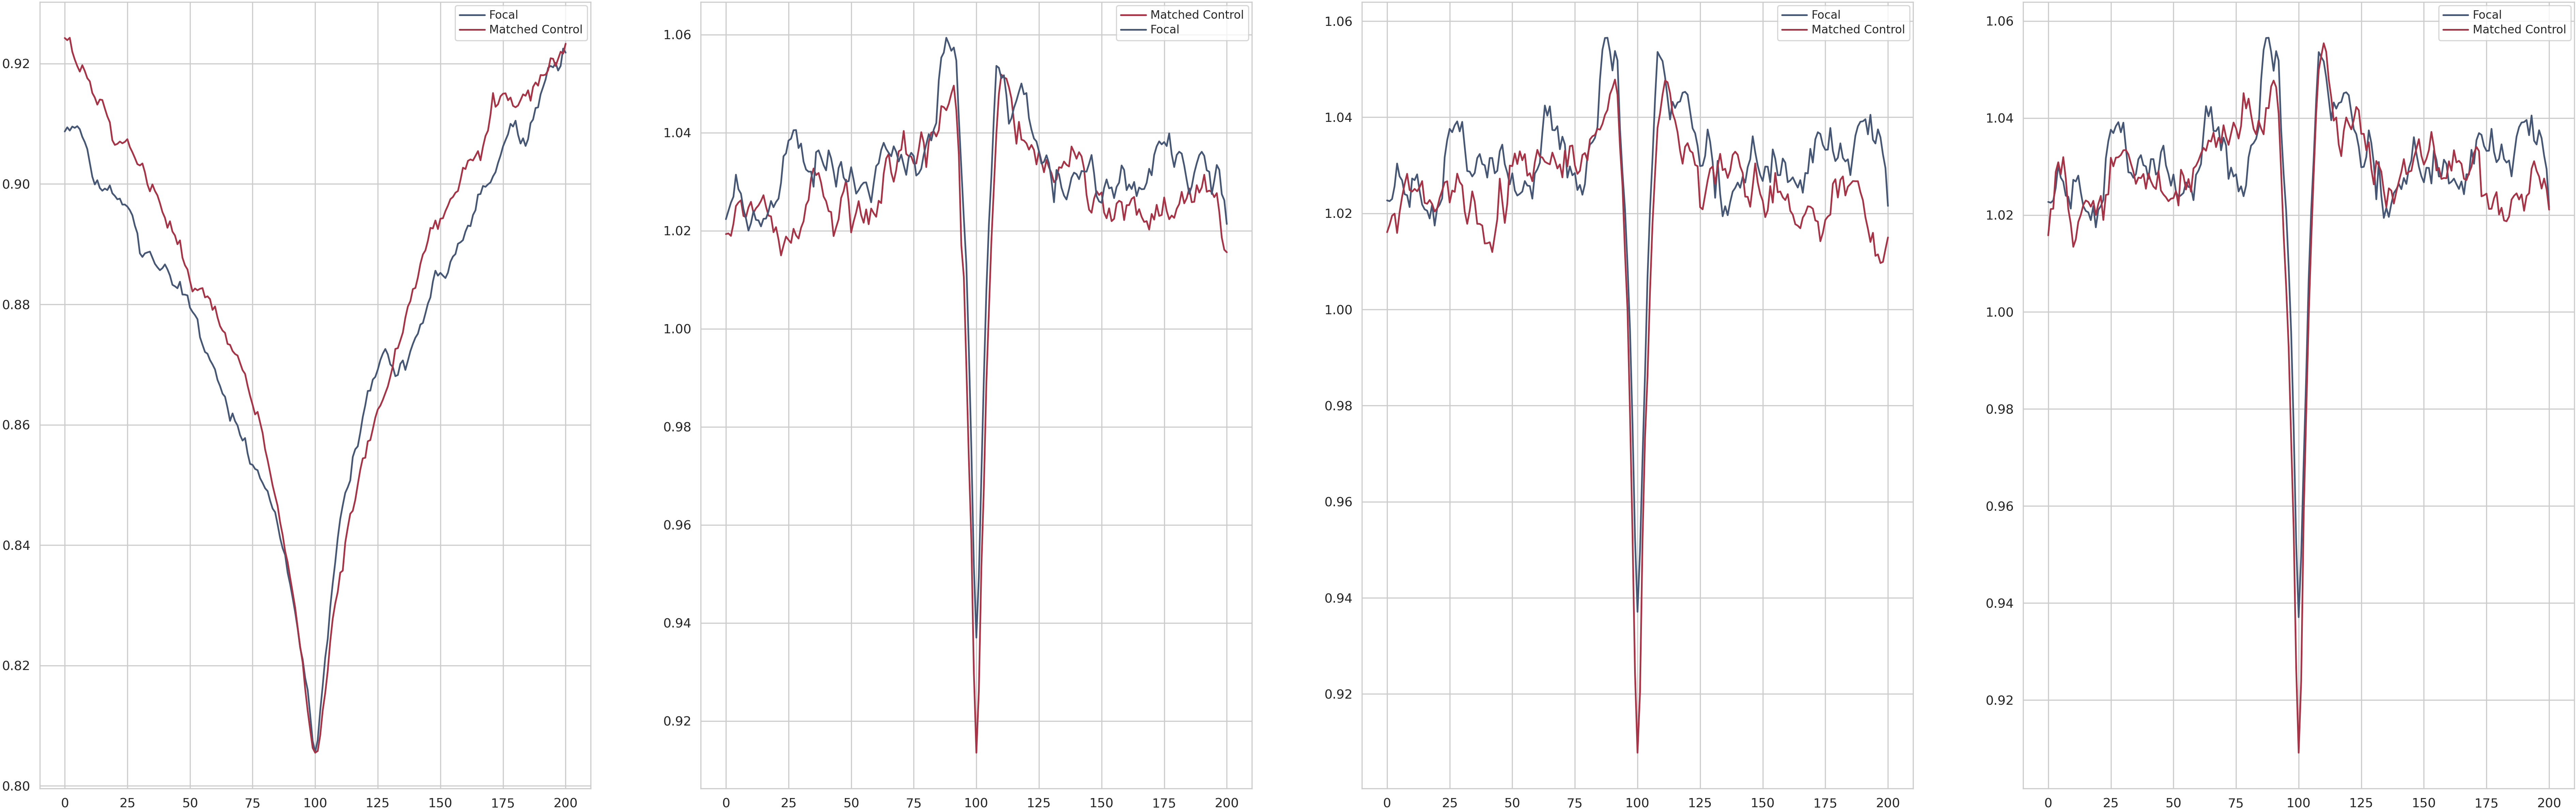

In [16]:
fig, ax = plt.subplots(1, 4, figsize=(32, 10), sharey=False)


def norm(arr):
    arr = arr.copy()
    return np.nanmedian(2 ** arr, axis=0)


sns.lineplot(norm(pc1_boundaries_focal), label='Focal', color=COLORS[0], ax=ax[0])
sns.lineplot(norm(pc1_boundaries_matched), label='Matched Control', color=COLORS[1], ax=ax[0])

sns.lineplot(norm(atac_h3k4me3_boundaries_matched), label='Matched Control', color=COLORS[1], ax=ax[1])
sns.lineplot(norm(atac_h3k4me3_boundaries_focal), label='Focal', color=COLORS[0], ax=ax[1])

sns.lineplot(norm(h3k4me1_h3k27ac_boundaries_focal), label='Focal', color=COLORS[0], ax=ax[2])
sns.lineplot(norm(h3k4me1_h3k27ac_boundaries_matched), label='Matched Control', color=COLORS[1], ax=ax[2])

sns.lineplot(norm(pol2_boundaries_focal), label='Focal', color=COLORS[0], ax=ax[3])
sns.lineplot(norm(pol2_boundaries_matched), label='Matched Control', color=COLORS[1], ax=ax[3])

### apa

In [17]:
from coolpuppy import coolpup
from ggner_3d.cm import get_expected_cis_df, prepare_view_df, CLR_CONNS
view_df = prepare_view_df(arm=False)
clr = CLR_CONNS(10000)['WTnoUV']
expected = get_expected_cis_df('WTnoUV', resolution_kb=10, label='chrom')

cov_pup = {}

flank = 500_000
# for cov in ['pc1_10kb', 'atac_signal_h3k4me3_signal', 'h3k4me1_signal_h3k27ac_signal', 'pol2']:
for cov in ['atac_signal_h3k4me3_signal', 'pol2']:
    data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_{cov}.csv') if cov != 'pc1_10kb' else pd.read_csv(f'{data_dir}/ws_1000000/grid_search_data_{cov}.csv')
    split_dfs = split_df(data_df)

    focal_df = split_dfs['Focal']
    matched_df = split_dfs['Matched Control']

    focal_pup = coolpup.pileup(
        clr, 
        focal_df, 
        features_format='bed', 
        view_df=view_df, 
        local=True, 
        expected_df=expected, 
        flank=flank, 
        clr_weight_name='sweight',
        nproc=6)

    matched_pup = coolpup.pileup(
        clr, 
        matched_df, 
        features_format='bed', 
        view_df=view_df, 
        local=True, 
        expected_df=expected, 
        flank=flank, 
        clr_weight_name='sweight',
        nproc=6)
    cov_pup[cov] = (focal_pup, matched_pup)

Focal: 2442 samples
Matched Control: 2442 samples
Unmatched Control: 20348 samples
Control Pool: 22790 samples


INFO:coolpuppy:('chr6', 'chr6'): 10
INFO:coolpuppy:('chr4', 'chr4'): 6
INFO:coolpuppy:('chr5', 'chr5'): 29
INFO:coolpuppy:('chr3', 'chr3'): 48
INFO:coolpuppy:('chr1', 'chr1'): 89
INFO:coolpuppy:('chr9', 'chr9'): 66
INFO:coolpuppy:('chr2', 'chr2'): 219
INFO:coolpuppy:('chr7', 'chr7'): 205
INFO:coolpuppy:('chr11', 'chr11'): 36
INFO:coolpuppy:('chr10', 'chr10'): 143
INFO:coolpuppy:('chr13', 'chr13'): 14
INFO:coolpuppy:('chr8', 'chr8'): 365
INFO:coolpuppy:('chr12', 'chr12'): 116
INFO:coolpuppy:('chr14', 'chr14'): 166
INFO:coolpuppy:('chr16', 'chr16'): 25
INFO:coolpuppy:('chr15', 'chr15'): 151
INFO:coolpuppy:('chr19', 'chr19'): 38
INFO:coolpuppy:('chr17', 'chr17'): 337
INFO:coolpuppy:('chr18', 'chr18'): 34
INFO:coolpuppy:('chr21', 'chr21'): 30
INFO:coolpuppy:('chr22', 'chr22'): 158
INFO:coolpuppy:('chr20', 'chr20'): 128
INFO:coolpuppy:Total number of piled up windows: 2413
INFO:coolpuppy:('chr6', 'chr6'): 168
INFO:coolpuppy:('chr4', 'chr4'): 112
INFO:coolpuppy:('chr5', 'chr5'): 152
INFO:coo

Focal: 1628 samples
Matched Control: 1628 samples
Unmatched Control: 22790 samples
Control Pool: 24418 samples


INFO:coolpuppy:('chr4', 'chr4'): 1
INFO:coolpuppy:('chr6', 'chr6'): 3
INFO:coolpuppy:('chr5', 'chr5'): 14
INFO:coolpuppy:('chr3', 'chr3'): 24
INFO:coolpuppy:('chr1', 'chr1'): 37
INFO:coolpuppy:('chr9', 'chr9'): 30
INFO:coolpuppy:('chr2', 'chr2'): 116
INFO:coolpuppy:('chr7', 'chr7'): 174
INFO:coolpuppy:('chr11', 'chr11'): 11
INFO:coolpuppy:('chr13', 'chr13'): 6
INFO:coolpuppy:('chr10', 'chr10'): 86
INFO:coolpuppy:('chr8', 'chr8'): 312
INFO:coolpuppy:('chr12', 'chr12'): 77
INFO:coolpuppy:('chr16', 'chr16'): 4
INFO:coolpuppy:('chr14', 'chr14'): 110
INFO:coolpuppy:('chr15', 'chr15'): 86
INFO:coolpuppy:('chr19', 'chr19'): 33
INFO:coolpuppy:('chr17', 'chr17'): 253
INFO:coolpuppy:('chr18', 'chr18'): 27
INFO:coolpuppy:('chr21', 'chr21'): 12
INFO:coolpuppy:('chr22', 'chr22'): 127
INFO:coolpuppy:('chr20', 'chr20'): 66
INFO:coolpuppy:Total number of piled up windows: 1609
INFO:coolpuppy:('chr5', 'chr5'): 101
INFO:coolpuppy:('chr4', 'chr4'): 86
INFO:coolpuppy:('chr6', 'chr6'): 117
INFO:coolpuppy:(

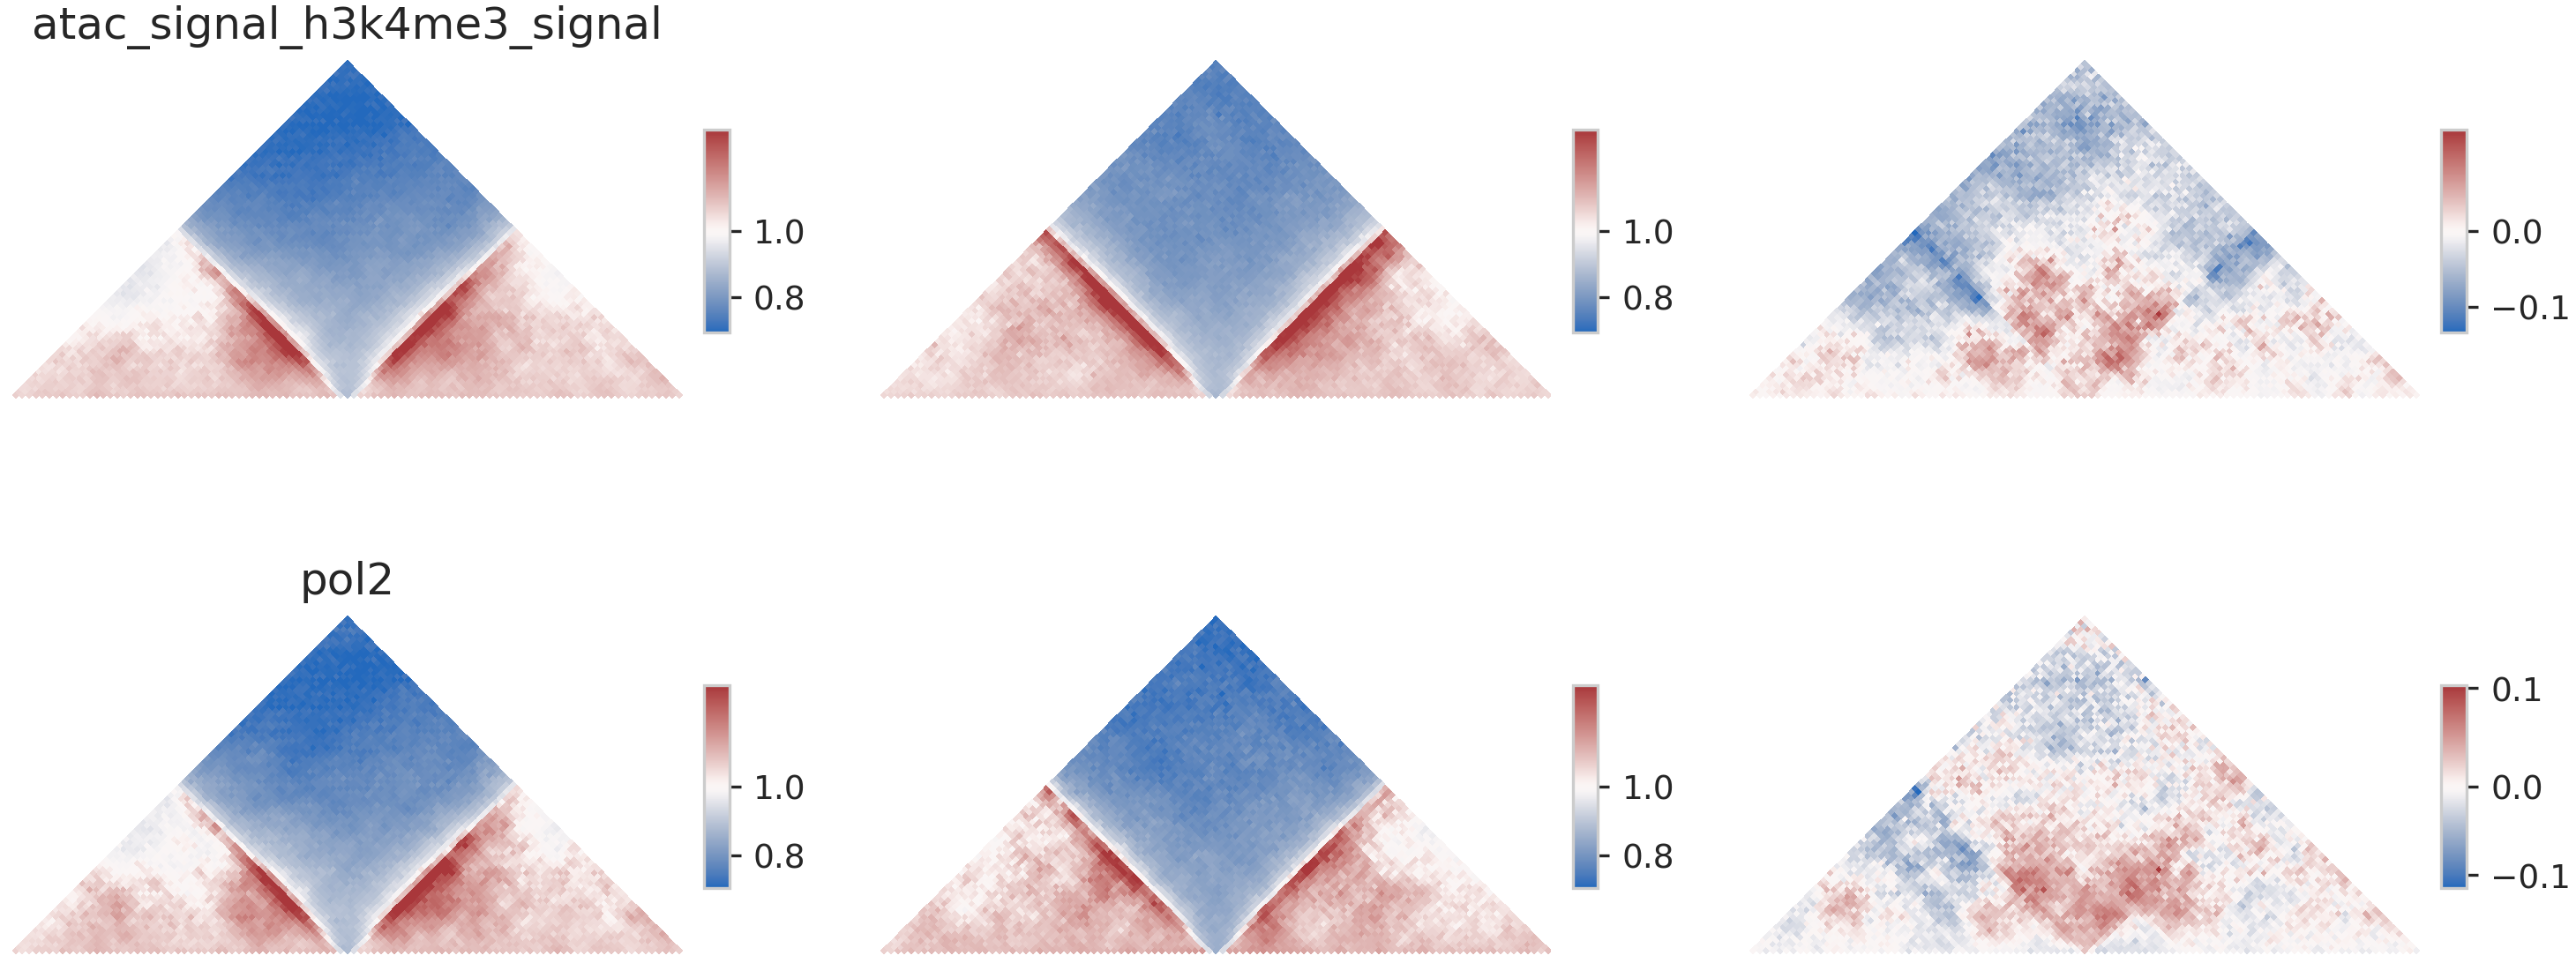

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))

for i, (cov, (focal_pup, matched_pup)) in enumerate(cov_pup.items()):

    vmin, vmax = np.nanpercentile(focal_pup['data'][0], [1, 99])
    plotting.hic_upper_triangle(
        focal_pup['data'][0],
        cmap="vlag",
        center=1,
        vmin=vmin, vmax=vmax,
        ax=ax[i, 0],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8))

    plotting.hic_upper_triangle(
        matched_pup['data'][0],
        cmap="vlag",
        center=1,
        vmin=vmin, vmax=vmax,
        ax=ax[i, 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8))
    
    plotting.hic_upper_triangle(
        focal_pup['data'][0] - matched_pup['data'][0],
        cmap="vlag",
        center=0,
        ax=ax[i, 2],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8))

for i, (cov, (focal_pup, matched_pup)) in enumerate(cov_pup.items()):
    ax[i, 0].set_title(cov)

### pol2 levels

In [22]:
pol2_dict = {'wtnouv_pol2': ['/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw']}
atac_wt_dict = {
    'wt_nouv_atac': [
    '/home/carlos/Clone/ctcf_xpc/atac_seq/GSM7089925_ATACseq_WT_noUV_Rep1.bw',
    '/home/carlos/Clone/ctcf_xpc/atac_seq/GSM7089926_ATACseq_WT_noUV_Rep2.bw'
]}

import bbi

def stackup_bw_dict(bw_dict, df, nbins=150, summary='sum'):
    bw_dict_rep_avg = {}
    for k, bw_list in bw_dict.items():
        bw_dict_rep_avg[k] = []
        for bw_path in bw_list:
            current_stackup = bbi.stackup(
                bw_path,
                df.chrom,
                df.flank_start,
                df.flank_end,
                bins=nbins,
                summary = summary,
            )
            bw_dict_rep_avg[k].append(current_stackup)
    bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
    return bw_dict_rep_avg

pol2_viz_list = []
flank = 250_000

# for cov in ['pc1_10kb', 'atac_signal_h3k4me3_signal', 'h3k4me1_signal_h3k27ac_signal', 'pol2', 'pol2_atac_signal']:
# for cov in ['pol2', 'atac_signal_h3k4me3_signal']:
for cov in ['pol2']:

    data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_{cov}.csv') if cov != 'pc1_10kb' else pd.read_csv(f'{data_dir}/ws_1000000/grid_search_data_{cov}.csv')
    split_dfs = split_df(data_df)

    focal_df = split_dfs['Focal'].copy()
    focal_df['flank_start'] = focal_df['start'] - flank
    focal_df['flank_end'] = focal_df['end'] + flank
    matched_df = split_dfs['Matched Control'].copy()
    matched_df['flank_start'] = matched_df['start'] - flank
    matched_df['flank_end'] = matched_df['end'] + flank

    focal_stackup = stackup_bw_dict(pol2_dict, focal_df)
    matched_stackup = stackup_bw_dict(pol2_dict, matched_df)

    pol2_viz_list.append((cov, focal_stackup, matched_stackup))

atac_viz_list = []
# for cov in ['pc1_10kb', 'atac_signal_h3k4me3_signal', 'h3k4me1_signal_h3k27ac_signal', 'pol2']:
for cov in ['pol2', 'atac_signal_h3k4me3_signal']:
# for cov in ['pol2']:

    data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_{cov}.csv') if cov != 'pc1_10kb' else pd.read_csv(f'{data_dir}/ws_1000000/grid_search_data_{cov}.csv')
    split_dfs = split_df(data_df)

    focal_df = split_dfs['Focal'].copy()
    focal_df['flank_start'] = focal_df['start'] - flank
    focal_df['flank_end'] = focal_df['end'] + flank
    matched_df = split_dfs['Matched Control'].copy()
    matched_df['flank_start'] = matched_df['start'] - flank
    matched_df['flank_end'] = matched_df['end'] + flank

    focal_stackup = stackup_bw_dict(atac_wt_dict, focal_df)
    matched_stackup = stackup_bw_dict(atac_wt_dict, matched_df)

    atac_viz_list.append((cov, focal_stackup, matched_stackup))

Focal: 1628 samples
Matched Control: 1628 samples
Unmatched Control: 22790 samples
Control Pool: 24418 samples


/tmp/ipykernel_306019/701403272.py:24: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


Focal: 1628 samples
Matched Control: 1628 samples
Unmatched Control: 22790 samples
Control Pool: 24418 samples


/tmp/ipykernel_306019/701403272.py:24: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


Focal: 2442 samples
Matched Control: 2442 samples
Unmatched Control: 20348 samples
Control Pool: 22790 samples


/tmp/ipykernel_306019/701403272.py:24: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


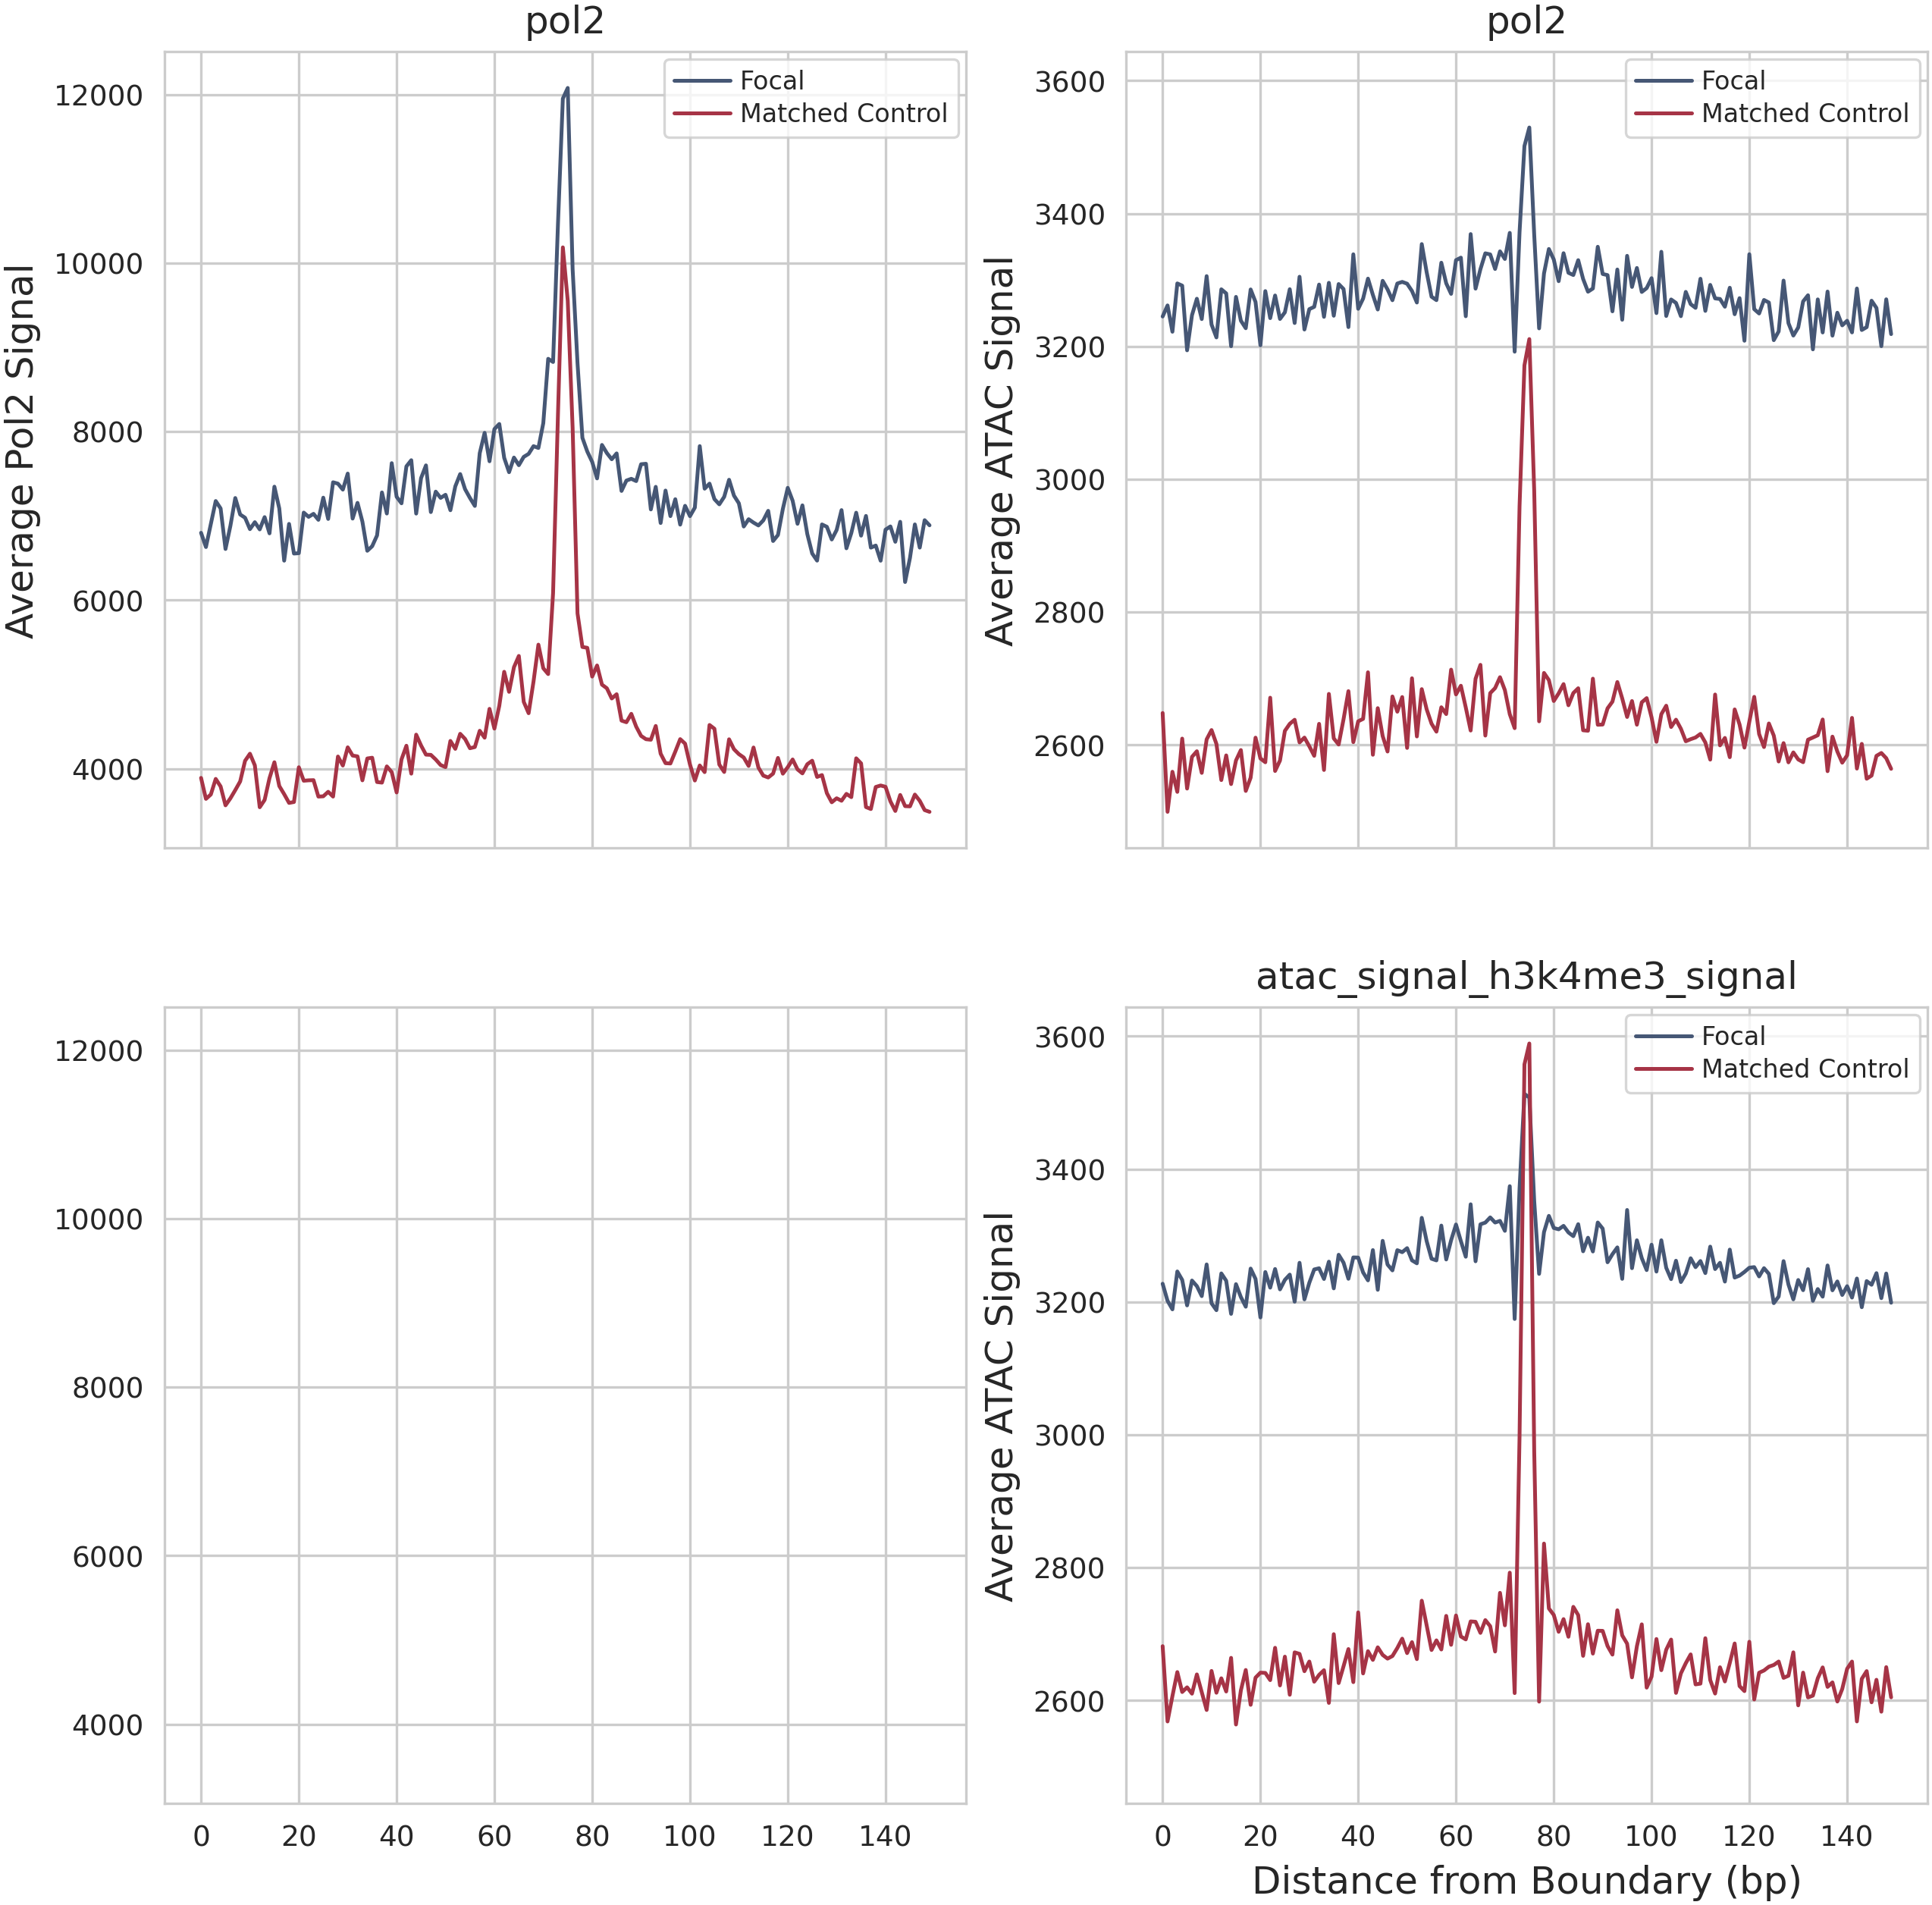

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey='col')
for i, (cov, focal_stackup, matched_stackup) in enumerate(pol2_viz_list):
    focal_data = np.nanmean(focal_stackup['wtnouv_pol2'], axis=0)
    matched_data = np.nanmean(matched_stackup['wtnouv_pol2'], axis=0)
    sns.lineplot(focal_data, label='Focal', color=COLORS[0], ax=axs[i, 0])
    sns.lineplot(matched_data, label='Matched Control', color=COLORS[1], ax=axs[i, 0])
    axs[i, 0].set_title(cov)
    axs[i, 0].set_xlabel('Distance from Boundary (bp)')
    axs[i, 0].set_ylabel('Average Pol2 Signal')
    axs[i, 0].legend()

for i, (cov, focal_stackup, matched_stackup) in enumerate(atac_viz_list):
    focal_data = np.nanmean(focal_stackup['wt_nouv_atac'], axis=0)
    matched_data = np.nanmean(matched_stackup['wt_nouv_atac'], axis=0)
    sns.lineplot(focal_data, label='Focal', color=COLORS[0], ax=axs[i, 1])
    sns.lineplot(matched_data, label='Matched Control', color=COLORS[1], ax=axs[i, 1])
    axs[i, 1].set_title(cov)
    axs[i, 1].set_xlabel('Distance from Boundary (bp)')
    axs[i, 1].set_ylabel('Average ATAC Signal')
    axs[i, 1].legend()

Focal: 1628 samples
Matched Control: 1628 samples
Unmatched Control: 22790 samples
Control Pool: 24418 samples


<Axes: xlabel='atac_signal_x', ylabel='atac_signal_y'>

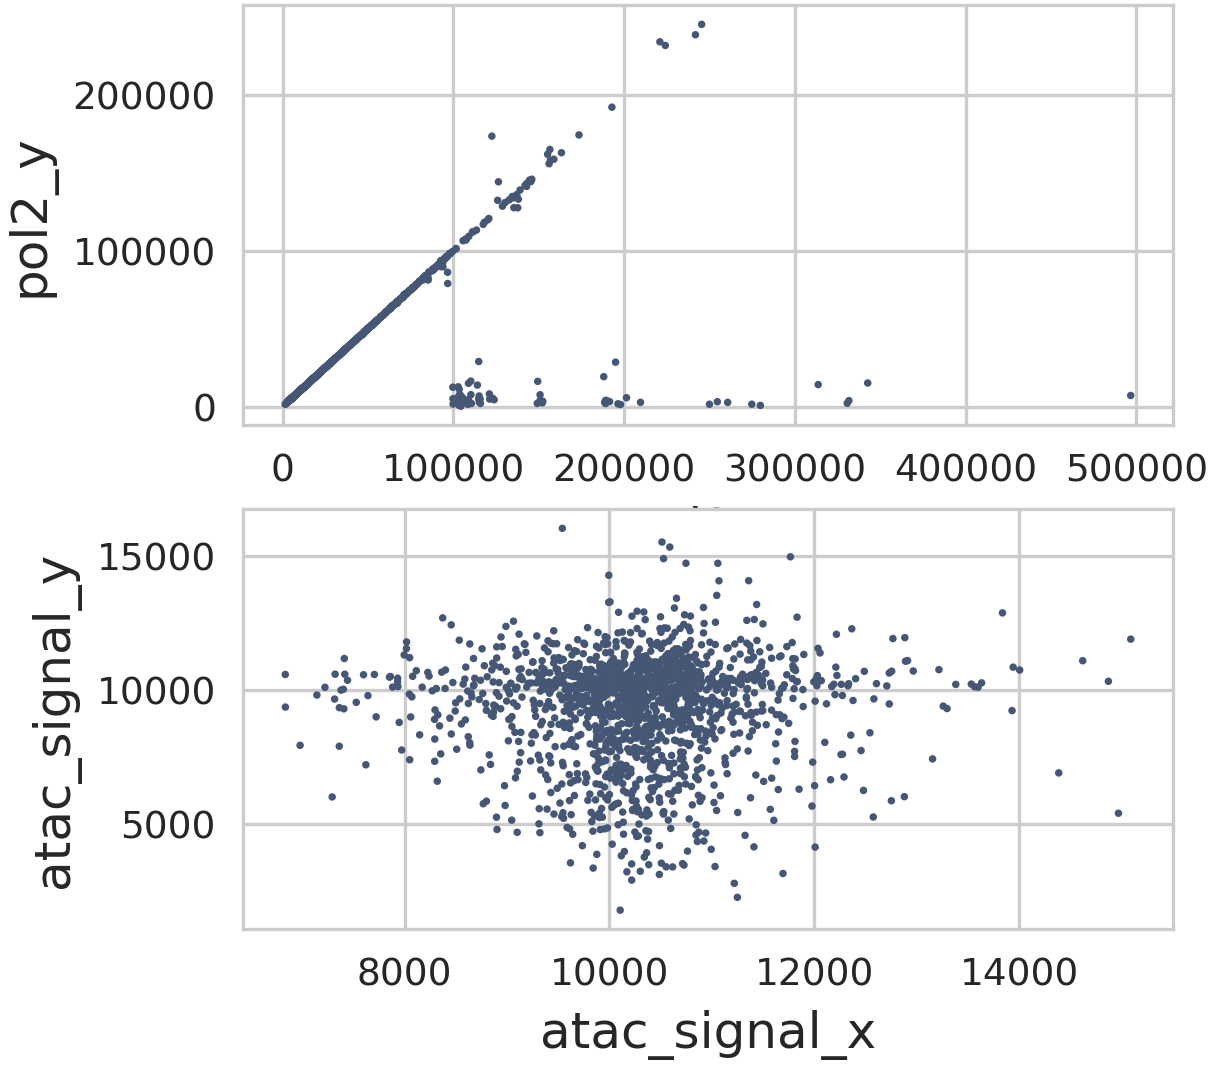

In [25]:
# cov in ['pc1_10kb', 'atac_signal_h3k4me3_signal', 'h3k4me1_signal_h3k27ac_signal', 'pol2']:
cov = 'pol2'
data_df = pd.read_csv(f'{data_dir}/ws_100000/grid_search_data_{cov}.csv') if cov != 'pc1_10kb' else pd.read_csv(f'{data_dir}/ws_1000000/grid_search_data_{cov}.csv')
split_dfs = split_df(data_df)
    
focal_df = split_dfs['Focal'].copy()
matched_df = split_dfs['Matched Control'].copy()

merged_df = pd.merge(
    focal_df.assign(Condition='Focal'),
    matched_df.assign(Condition='Matched Control'),
    on=['pair_id'],
)

fig, axs = plt.subplots(2, 1, figsize=(4, 4))
merged_df.plot.scatter(x='pol2_x', y='pol2_y', c=merged_df['Condition_x'].map({'Focal': COLORS[0], 'Matched Control': COLORS[1]}), ax=axs[0], s=1)
merged_df.plot.scatter(x='atac_signal_x', y='atac_signal_y', c=merged_df['Condition_x'].map({'Focal': COLORS[0], 'Matched Control': COLORS[1]}), ax=axs[1], s=1)